# Analyse des Données - Impact de la Publicité sur les Ventes

## Introduction

Ce notebook analyse les données transactionnelles d'une marque et l'impact de ses campagnes publicitaires (TV et Programmatique) sur les ventes.

### Datasets disponibles:
1. **retailer.csv**: Données transactionnelles du site web
2. **tv_publisher.csv**: Données publicitaires TV
3. **programmatic_publisher.csv**: Données publicitaires programmatiques (bannières web)
4. **mapping_transac_publisher_tv.csv**: Table de mapping entre clients, devices et dsp_id
5. **socio_demo.csv**: Données socio-démographiques des clients

### Objectifs:
1. Comprendre le marché avec des KPIs clés
2. Analyser l'impact de la publicité sur les ventes


In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliothèques importées avec succès")
print("✓ Polars activé pour les jointures optimisées")


✓ Bibliothèques importées avec succès
✓ Polars activé pour les jointures optimisées


## 1. Chargement des Données

**Note sur l'utilisation de Polars:**
- ⚡ **Polars** : bibliothèque principale pour toutes les opérations de données (10-100x plus rapide que Pandas)
- 📊 **Pandas** : utilisé uniquement pour les visualisations (conversion via `.to_pandas()` quand nécessaire)
- 🚀 Polars est écrit en Rust, optimisé pour les gros volumes, avec lazy evaluation et parallélisation automatique


In [2]:
# Chemins des fichiers
DATA_PATH = 'input_data/X_2025/'

print("🚀 Chargement des données avec Polars (optimisé pour la performance)...")
print("-" * 50)

# 1. Socio-démographie
print("1/5 Chargement socio_demo.csv...")
df_socio = pl.read_csv(DATA_PATH + 'socio_demo.csv')
print(f"   → {len(df_socio):,} lignes chargées")

# 2. Mapping (table de correspondance)
print("2/5 Chargement mapping_transac_publisher_tv.csv...")
df_mapping = pl.read_csv(DATA_PATH + 'mapping_transac_publisher_tv.csv')
print(f"   → {len(df_mapping):,} lignes chargées")

# 3. Retailer (données transactionnelles)
print("3/5 Chargement retailer.csv...")
df_retailer = pl.read_csv(
    DATA_PATH + 'retailer.csv',
    try_parse_dates=True
)
print(f"   → {len(df_retailer):,} lignes chargées")

# 4. TV Publisher
print("4/5 Chargement tv_publisher.csv...")
df_tv = pl.read_csv(
    DATA_PATH + 'tv_publisher.csv',
    try_parse_dates=True
)
print(f"   → {len(df_tv):,} lignes chargées")

# 5. Programmatic Publisher
print("5/5 Chargement programmatic_publisher.csv...")
df_prog = pl.read_csv(
    DATA_PATH + 'programmatic_publisher.csv',
    try_parse_dates=True
)
print(f"   → {len(df_prog):,} lignes chargées")

print("-" * 50)
print("✓ Toutes les données sont chargées avec Polars !")
print("💡 Polars = Rust + Lazy evaluation + Parallélisation automatique")


🚀 Chargement des données avec Polars (optimisé pour la performance)...
--------------------------------------------------
1/5 Chargement socio_demo.csv...
   → 1,354,584 lignes chargées
2/5 Chargement mapping_transac_publisher_tv.csv...
   → 7,984,411 lignes chargées
3/5 Chargement retailer.csv...
   → 9,866,049 lignes chargées
4/5 Chargement tv_publisher.csv...
   → 5,827,133 lignes chargées
5/5 Chargement programmatic_publisher.csv...
   → 17,493,428 lignes chargées
--------------------------------------------------
✓ Toutes les données sont chargées avec Polars !
💡 Polars = Rust + Lazy evaluation + Parallélisation automatique


In [3]:
# Aperçu rapide des données
print("APERÇU DES DONNÉES")
print("=" * 80)

datasets = {
    'Retailer': df_retailer,
    'TV Publisher': df_tv,
    'Programmatic': df_prog,
    'Mapping': df_mapping,
    'Socio-Demo': df_socio
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"  - Shape: {df.shape}")
    print(f"  - Colonnes: {df.columns}")
    print(f"  - Mémoire estimée: {df.estimated_size('mb'):.2f} MB")


APERÇU DES DONNÉES

Retailer:
  - Shape: (9866049, 7)
  - Colonnes: ['customer_id', 'timestamp_utc', 'event_name', 'brand', 'product_name', 'sales', 'quantity']
  - Mémoire estimée: 905.28 MB

TV Publisher:
  - Shape: (5827133, 3)
  - Colonnes: ['device_id', 'timestamp_utc', 'cost_milli_cent']
  - Mémoire estimée: 154.78 MB

Programmatic:
  - Shape: (17493428, 5)
  - Colonnes: ['dsp_id', 'timestamp_utc', 'campaign_name', 'device_type', 'cost_milli_cent']
  - Mémoire estimée: 946.43 MB

Mapping:
  - Shape: (7984411, 3)
  - Colonnes: ['customer_id', 'dsp_id', 'device_id']
  - Mémoire estimée: 433.21 MB

Socio-Demo:
  - Shape: (1354584, 4)
  - Colonnes: ['customer_id', 'breed', 'age', 'income']
  - Mémoire estimée: 55.64 MB


## 2. Exploration et Nettoyage des Données


In [4]:
# Vérification des valeurs manquantes
print("VALEURS MANQUANTES")
print("=" * 80)

for name, df in datasets.items():
    missing = df.null_count()
    total_missing = missing.select(pl.sum_horizontal(pl.all())).item()
    if total_missing > 0:
        print(f"\n{name}:")
        # Afficher les colonnes avec des valeurs manquantes
        for col in df.columns:
            null_count = df[col].null_count()
            if null_count > 0:
                print(f"  {col}: {null_count}")
    else:
        print(f"\n{name}: ✓ Aucune valeur manquante")


VALEURS MANQUANTES

Retailer:
  brand: 277240
  product_name: 277240
  sales: 8426738
  quantity: 8426738

TV Publisher: ✓ Aucune valeur manquante

Programmatic: ✓ Aucune valeur manquante

Mapping:
  device_id: 158701

Socio-Demo: ✓ Aucune valeur manquante


In [5]:
# Statistiques descriptives - Retailer
print("STATISTIQUES DESCRIPTIVES - RETAILER")
print("=" * 80)
print(df_retailer.head(10))
print("\nTypes d'événements:")
print(df_retailer.group_by('event_name').agg(pl.len().alias('count')).sort('count', descending=True))
print("\nPériode couverte:")
print(f"  Du {df_retailer['timestamp_utc'].min()} au {df_retailer['timestamp_utc'].max()}")


STATISTIQUES DESCRIPTIVES - RETAILER
shape: (10, 7)
┌────────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────┬──────────┐
│ customer_id    ┆ timestamp_utc ┆ event_name    ┆ brand        ┆ product_name  ┆ sales ┆ quantity │
│ ---            ┆ ---           ┆ ---           ┆ ---          ┆ ---           ┆ ---   ┆ ---      │
│ str            ┆ datetime[μs]  ┆ str           ┆ str          ┆ str           ┆ f64   ┆ f64      │
╞════════════════╪═══════════════╪═══════════════╪══════════════╪═══════════════╪═══════╪══════════╡
│ reFs5GI87lXJkJ ┆ 2024-02-07    ┆ Product Page  ┆ null         ┆ null          ┆ null  ┆ null     │
│ Si9r           ┆ 02:27:10      ┆ View          ┆              ┆               ┆       ┆          │
│ reFs5GI87lXJkJ ┆ 2024-06-12    ┆ Product Page  ┆ Science Diet ┆ SD Fel A7+    ┆ null  ┆ null     │
│ Si9r           ┆ 16:16:54      ┆ View          ┆              ┆ SavCknEnt     ┆       ┆          │
│                ┆               ┆     

## 3. Analyse du Marché - KPIs Clés

### 3.1 Vue d'ensemble des transactions


In [6]:
# Filtrer uniquement les transactions (achats) - Syntaxe Polars
# Note: l'événement pour les achats est 'Order' et non 'transaction'
df_purchases = df_retailer.filter(pl.col('event_name') == 'Order')

print("VUE D'ENSEMBLE DES TRANSACTIONS")
print("=" * 80)
print(f"Nombre total de transactions: {len(df_purchases):,}")
print(f"Nombre de clients uniques: {df_purchases['customer_id'].n_unique():,}")
print(f"Nombre de produits uniques: {df_purchases['product_name'].n_unique():,}")
print(f"Nombre de marques: {df_purchases['brand'].n_unique():,}")
print(f"\nChiffre d'affaires total: {df_purchases['sales'].sum():,.2f} $")
print(f"Quantité totale vendue: {df_purchases['quantity'].sum():,.0f} unités")


VUE D'ENSEMBLE DES TRANSACTIONS
Nombre total de transactions: 1,439,311
Nombre de clients uniques: 502,026


Nombre de produits uniques: 494
Nombre de marques: 4

Chiffre d'affaires total: 62,427,949.18 $
Quantité totale vendue: 1,556,001 unités


In [7]:
# KPIs principaux
print("\nKPIS PRINCIPAUX")
print("=" * 80)

# Panier moyen
avg_basket = df_purchases['sales'].mean()
print(f"Panier moyen: {avg_basket:.2f} $")

# Panier moyen par acheteur (somme des achats / nombre de clients)
total_per_customer = df_purchases.group_by('customer_id').agg(pl.col('sales').sum())
avg_basket_per_buyer = total_per_customer['sales'].mean()
print(f"Panier moyen par acheteur (total dépenses): {avg_basket_per_buyer:.2f} $")

# Nombre moyen de transactions par client
transactions_per_customer = df_purchases.group_by('customer_id').agg(pl.len().alias('count'))
avg_transactions = transactions_per_customer['count'].mean()
print(f"Nombre moyen de transactions par client: {avg_transactions:.2f}")

# Prix moyen par unité
avg_unit_price = df_purchases['sales'].sum() / df_purchases['quantity'].sum()
print(f"Prix moyen par unité: {avg_unit_price:.2f} $")

# Quantité moyenne par transaction
avg_quantity = df_purchases['quantity'].mean()
print(f"Quantité moyenne par transaction: {avg_quantity:.2f} unités")



KPIS PRINCIPAUX
Panier moyen: 43.37 $


Panier moyen par acheteur (total dépenses): 124.35 $
Nombre moyen de transactions par client: 2.87
Prix moyen par unité: 40.12 $
Quantité moyenne par transaction: 1.08 unités


### 3.2 Distribution des ventes


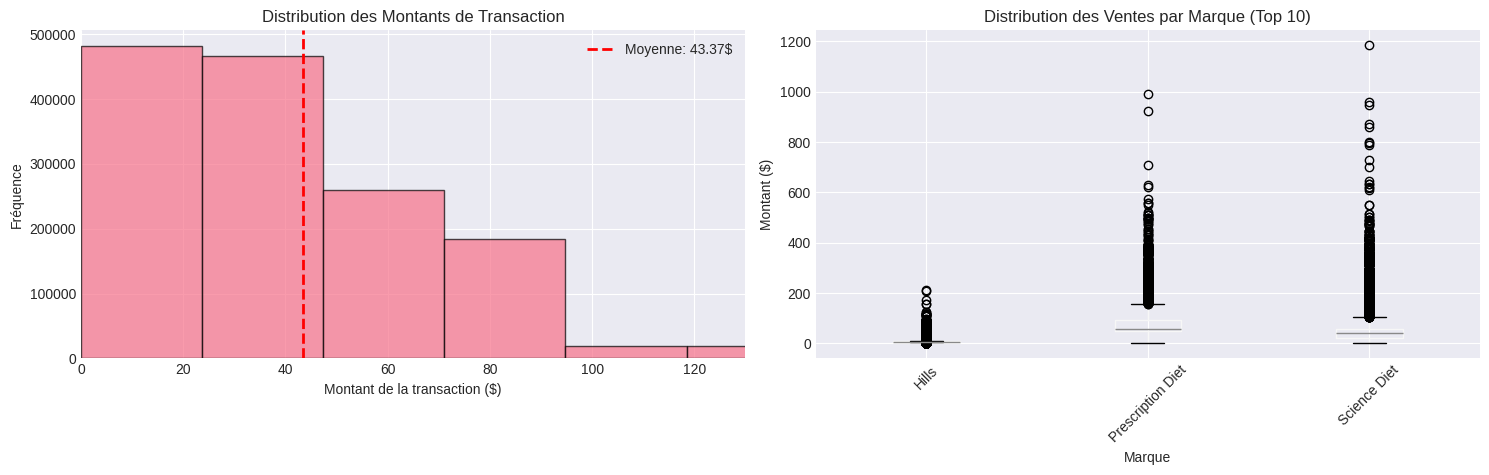

✓ Graphiques générés


In [8]:
# Graphique: Distribution du panier moyen
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme du montant des transactions
sales_data = df_purchases['sales'].to_numpy()
axes[0].hist(sales_data, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(avg_basket, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {avg_basket:.2f}$')
axes[0].set_xlabel('Montant de la transaction ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des Montants de Transaction')
axes[0].legend()
axes[0].set_xlim(0, df_purchases['sales'].quantile(0.99))

# Boxplot par marque (top 10)
top_brands = df_purchases.group_by('brand').agg(pl.len().alias('count')).sort('count', descending=True).head(10)['brand'].to_list()
df_top_brands = df_purchases.filter(pl.col('brand').is_in(top_brands)).to_pandas()
df_top_brands.boxplot(column='sales', by='brand', ax=axes[1], rot=45)
axes[1].set_xlabel('Marque')
axes[1].set_ylabel('Montant ($)')
axes[1].set_title('Distribution des Ventes par Marque (Top 10)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("✓ Graphiques générés")


### 3.3 Analyse temporelle des ventes


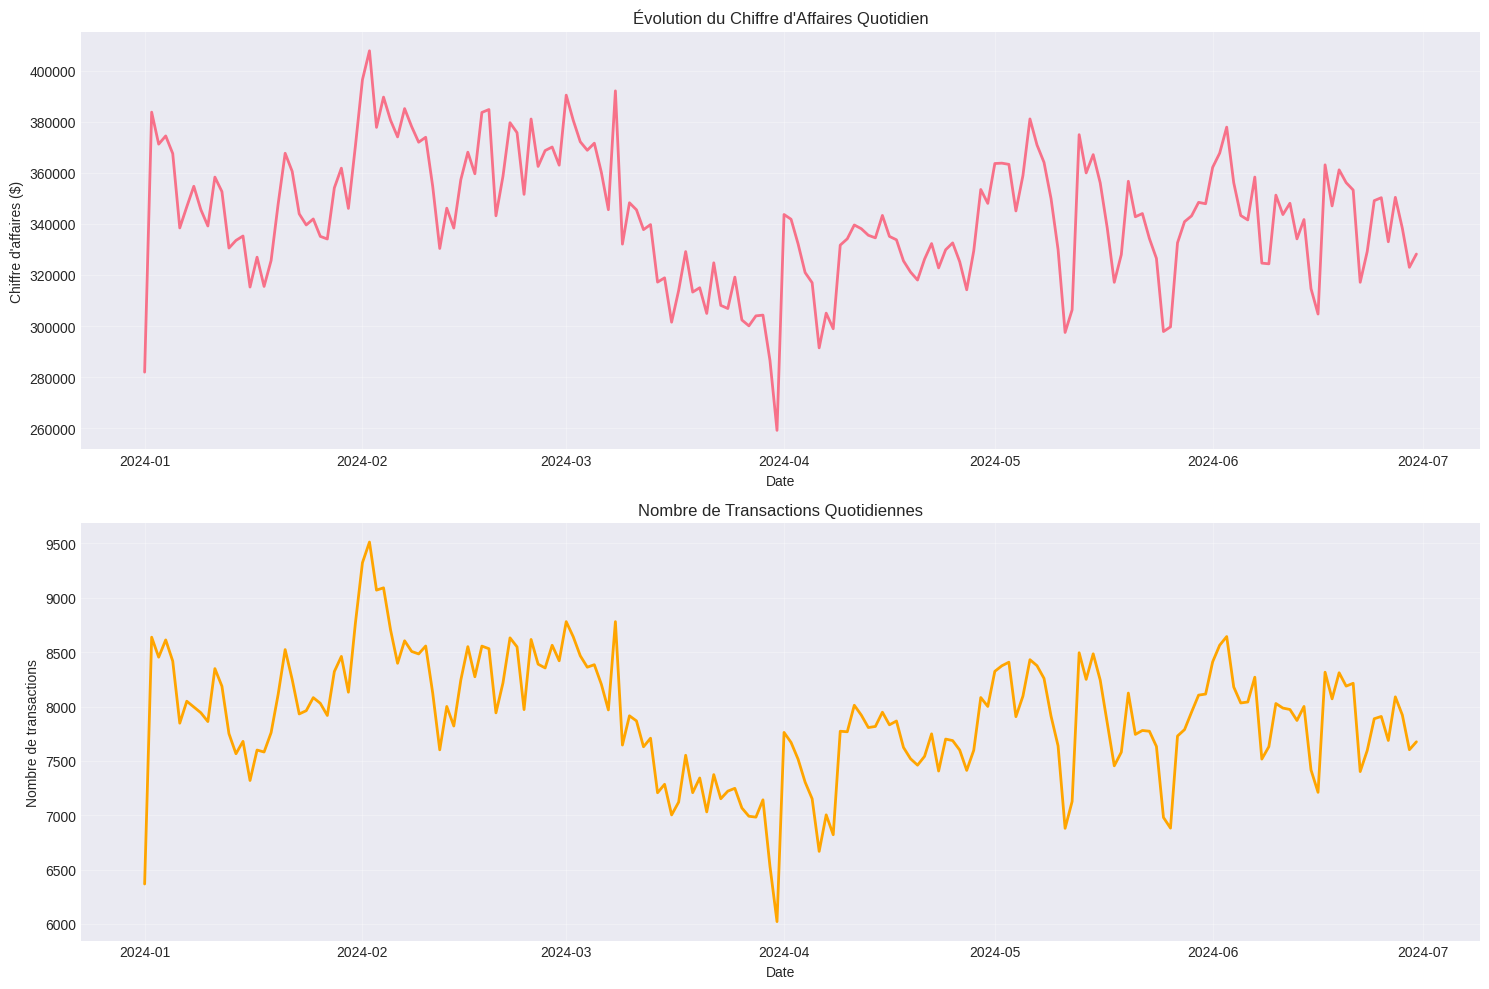

✓ Analyse temporelle effectuée


In [9]:
# Evolution des ventes dans le temps
daily_sales = df_purchases.with_columns(
    pl.col('timestamp_utc').cast(pl.Date).alias('date')
).group_by('date').agg([
    pl.col('sales').sum().alias('revenue'),
    pl.len().alias('transactions')
]).sort('date')

# Convertir en pandas pour matplotlib
daily_sales_pd = daily_sales.to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Chiffre d'affaires quotidien
axes[0].plot(daily_sales_pd['date'], daily_sales_pd['revenue'], linewidth=2)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Chiffre d\'affaires ($)')
axes[0].set_title('Évolution du Chiffre d\'Affaires Quotidien')
axes[0].grid(True, alpha=0.3)

# Nombre de transactions quotidiennes
axes[1].plot(daily_sales_pd['date'], daily_sales_pd['transactions'], linewidth=2, color='orange')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Nombre de transactions')
axes[1].set_title('Nombre de Transactions Quotidiennes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Analyse temporelle effectuée")


### 3.4 Analyse par marque et produit


TOP 10 MARQUES PAR CHIFFRE D'AFFAIRES
shape: (4, 4)
┌───────────────────┬───────────┬────────────┬──────────────┐
│ brand             ┆ revenue   ┆ quantity   ┆ transactions │
│ ---               ┆ ---       ┆ ---        ┆ ---          │
│ str               ┆ f64       ┆ f64        ┆ u32          │
╞═══════════════════╪═══════════╪════════════╪══════════════╡
│ Science Diet      ┆ 5.2632e7  ┆ 1.264559e6 ┆ 1201422      │
│ Prescription Diet ┆ 7.9477e6  ┆ 131021.0   ┆ 116815       │
│ Hills             ┆ 1.1486e6  ┆ 151019.0   ┆ 112298       │
│ Other             ┆ 699706.15 ┆ 9402.0     ┆ 8776         │
└───────────────────┴───────────┴────────────┴──────────────┘


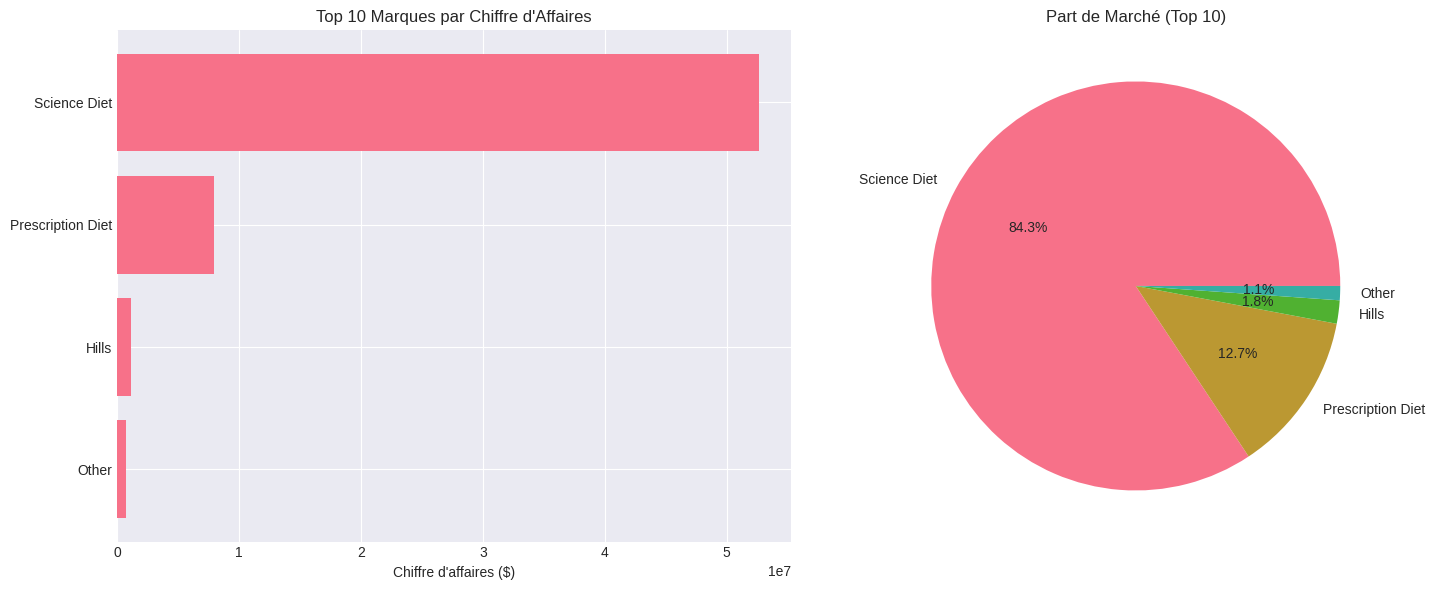

In [10]:
# Top 10 marques par chiffre d'affaires - Syntaxe Polars
brand_performance = (
    df_purchases.fill_null("Other")  # Filtrer les valeurs nulles
    .group_by('brand')
    .agg([
        pl.col('sales').sum().alias('revenue'),
        pl.col('quantity').sum().alias('quantity'),
        pl.col('customer_id').count().alias('transactions')
    ])
    .sort('revenue', descending=True)
)

print("TOP 10 MARQUES PAR CHIFFRE D'AFFAIRES")
print("=" * 80)
print(brand_performance.head(10))

# Visualisation - Conversion en Pandas pour matplotlib
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 marques par CA
top10_brands = brand_performance.head(10).to_pandas()
axes[0].barh(top10_brands['brand'], top10_brands['revenue'])
axes[0].set_xlabel('Chiffre d\'affaires ($)')
axes[0].set_title('Top 10 Marques par Chiffre d\'Affaires')
axes[0].invert_yaxis()

# Part de marché (top 10)
axes[1].pie(top10_brands['revenue'], labels=top10_brands['brand'], autopct='%1.1f%%')
axes[1].set_title('Part de Marché (Top 10)')

plt.tight_layout()
plt.show()



TOP 15 PRODUITS PAR CHIFFRE D'AFFAIRES
shape: (15, 4)
┌─────────────────────────────────┬───────────┬──────────┬──────────────┐
│ product                         ┆ revenue   ┆ quantity ┆ transactions │
│ ---                             ┆ ---       ┆ ---      ┆ ---          │
│ str                             ┆ f64       ┆ f64      ┆ u32          │
╞═════════════════════════════════╪═══════════╪══════════╪══════════════╡
│ SD Ca Adt SenSt&Sk Ckn 30lb bg  ┆ 2.1262e6  ┆ 26323.0  ┆ 25833        │
│ SD Ca Adt SenSt&Sk Tk&RStew 12… ┆ 1.4815e6  ┆ 32068.0  ┆ 27854        │
│ SD Ca Adt LB Ckn 35lb Sh        ┆ 1.0595e6  ┆ 13463.0  ┆ 13116        │
│ SD Ca Adt Ckn 35lb Sh           ┆ 1035124.3 ┆ 13177.0  ┆ 12925        │
│ SD Ca Adt SmPws Ckn 15.5lb bg   ┆ 935143.43 ┆ 17049.0  ┆ 16746        │
│ …                               ┆ …         ┆ …        ┆ …            │
│ SD Ca Adt SmPws Ckn 4.5lb bg    ┆ 806912.46 ┆ 36662.0  ┆ 35600        │
│ SD Ca Adt SenSt&Sk Sm&Min Ckn … ┆ 793763.87 ┆ 36044.0  

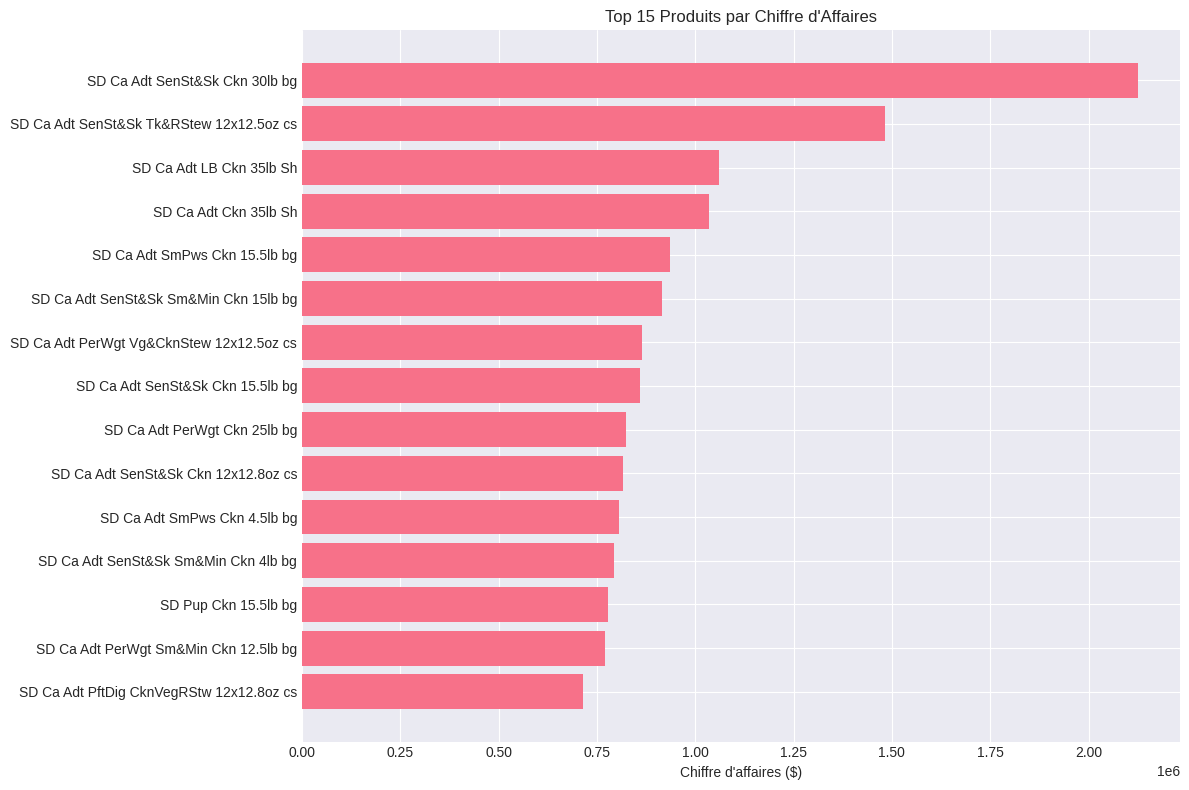

In [11]:
# Top 15 produits - Syntaxe Polars
product_performance = df_purchases.group_by('product_name').agg([
    pl.col('sales').sum().alias('revenue'),
    pl.col('quantity').sum().alias('quantity'),
    pl.col('customer_id').count().alias('transactions')
]).sort('revenue', descending=True).rename({'product_name': 'product'})

print("\nTOP 15 PRODUITS PAR CHIFFRE D'AFFAIRES")
print("=" * 80)
print(product_performance.head(15))

# Visualisation - Conversion en Pandas pour matplotlib
plt.figure(figsize=(12, 8))
top15_products = product_performance.head(15).to_pandas()
plt.barh(range(len(top15_products)), top15_products['revenue'])
plt.yticks(range(len(top15_products)), top15_products['product'])
plt.xlabel('Chiffre d\'affaires ($)')
plt.title('Top 15 Produits par Chiffre d\'Affaires')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 3.5 Analyse socio-démographique


In [12]:
# Merge avec les données socio-démographiques - Polars join
df_purchases_socio = df_purchases.join(df_socio, on='customer_id', how='left')

print("ANALYSE SOCIO-DÉMOGRAPHIQUE")
print("=" * 80)

# Distribution par âge
print("\nDistribution par âge:")
age_dist = df_socio.group_by('age').agg(pl.len().alias('count')).sort('age')
print(age_dist)

# Distribution par revenu
print("\nDistribution par revenu:")
income_dist = df_socio.group_by('income').agg(pl.len().alias('count')).sort('count', descending=True)
print(income_dist)

# Distribution par breed
print("\nDistribution par breed:")
breed_dist = df_socio.group_by('breed').agg(pl.len().alias('count')).sort('count', descending=True)
print(breed_dist)


ANALYSE SOCIO-DÉMOGRAPHIQUE

Distribution par âge:
shape: (6, 2)
┌─────────┬────────┐
│ age     ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ [18-25[ ┆ 182198 │
│ [25-35[ ┆ 244938 │
│ [35-45[ ┆ 203624 │
│ [45-55[ ┆ 230629 │
│ [55-65[ ┆ 236190 │
│ [65+[   ┆ 257005 │
└─────────┴────────┘

Distribution par revenu:
shape: (5, 2)
┌─────────────┬────────┐
│ income      ┆ count  │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ [120-200K$[ ┆ 297276 │
│ [200K$+[    ┆ 284399 │
│ [40-80K$[   ┆ 279708 │
│ [80-120K$[  ┆ 279688 │
│ [0-40K$[    ┆ 213513 │
└─────────────┴────────┘

Distribution par breed:
shape: (2, 2)
┌─────────────┬────────┐
│ breed       ┆ count  │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ Purebred    ┆ 827017 │
│ Mixed-breed ┆ 527567 │
└─────────────┴────────┘


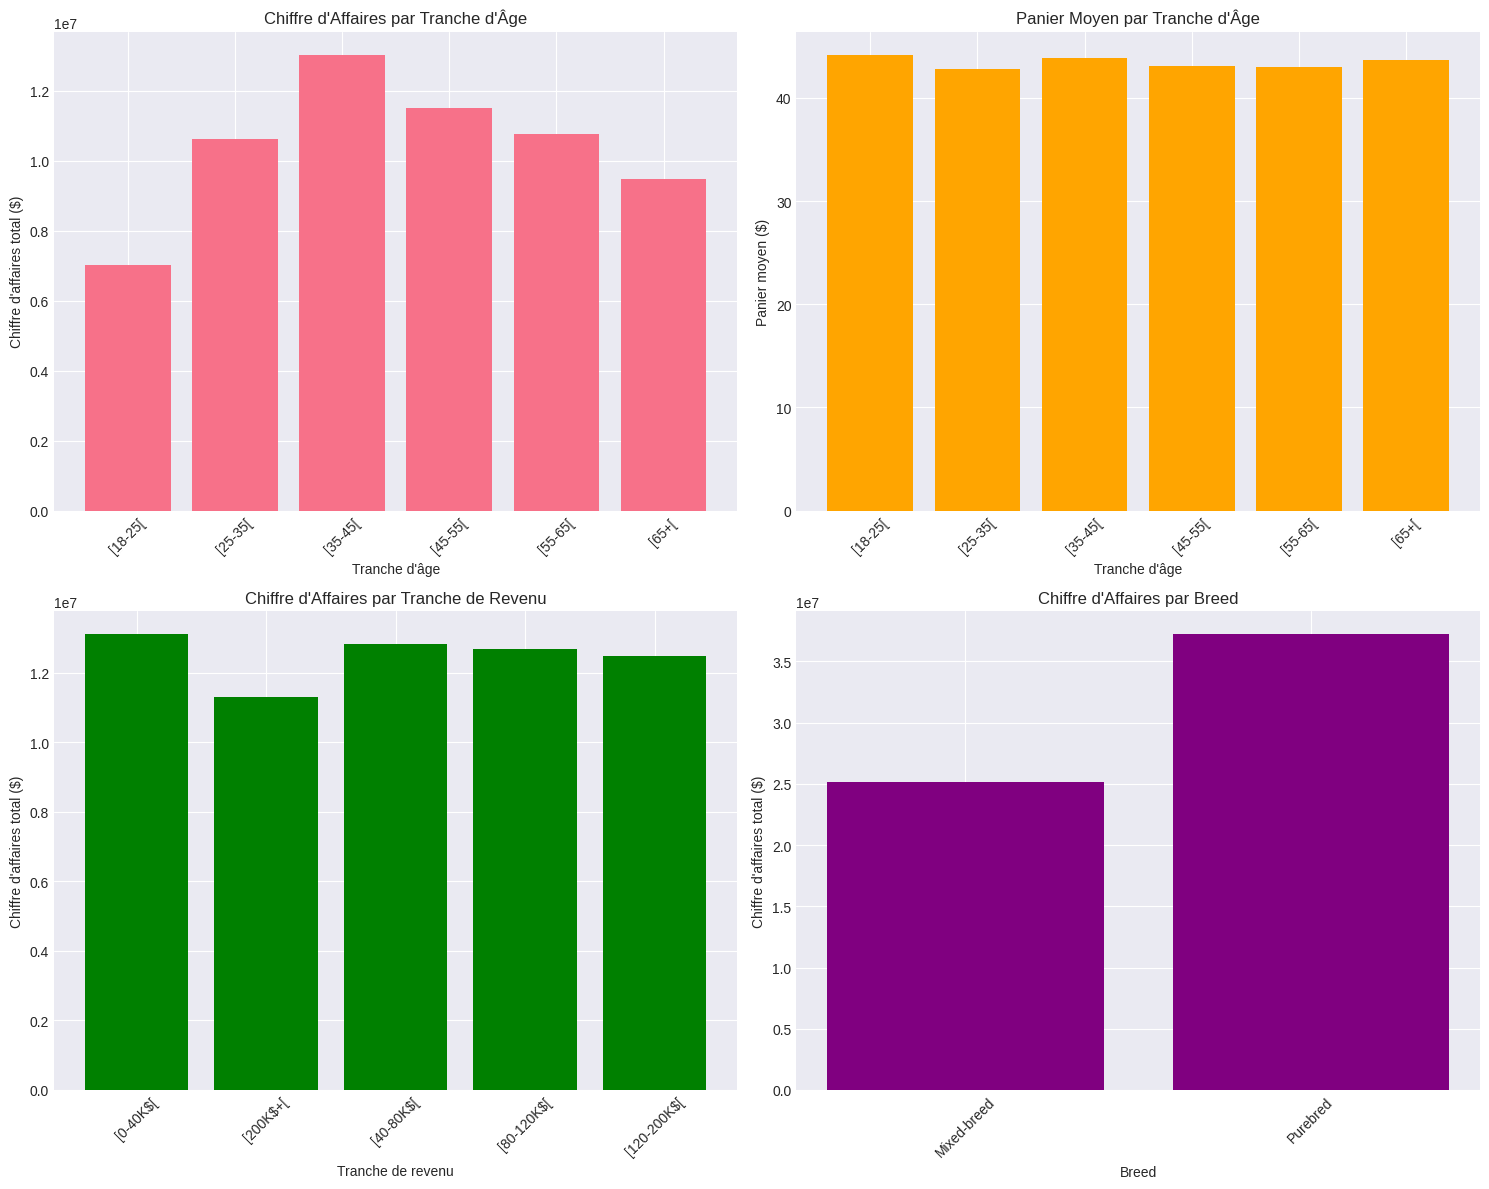


✓ Analyse socio-démographique complétée


In [13]:
# Performance par segment socio-démographique - Polars
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Ventes par âge - Conversion en Pandas pour viz
age_sales = (
    df_purchases_socio
    .filter(pl.col('age').is_not_null())
    .group_by('age')
    .agg([
        pl.col('sales').sum().alias('sum'),
        pl.col('sales').mean().alias('mean'),
        pl.len().alias('count')
    ])
    .sort('age')
    .to_pandas()
)

axes[0, 0].bar(range(len(age_sales)), age_sales['sum'])
axes[0, 0].set_xticks(range(len(age_sales)))
axes[0, 0].set_xticklabels(age_sales['age'], rotation=45)
axes[0, 0].set_xlabel('Tranche d\'âge')
axes[0, 0].set_ylabel('Chiffre d\'affaires total ($)')
axes[0, 0].set_title('Chiffre d\'Affaires par Tranche d\'Âge')

# Panier moyen par âge
axes[0, 1].bar(range(len(age_sales)), age_sales['mean'], color='orange')
axes[0, 1].set_xticks(range(len(age_sales)))
axes[0, 1].set_xticklabels(age_sales['age'], rotation=45)
axes[0, 1].set_xlabel('Tranche d\'âge')
axes[0, 1].set_ylabel('Panier moyen ($)')
axes[0, 1].set_title('Panier Moyen par Tranche d\'Âge')

# Ventes par revenu
income_sales = (
    df_purchases_socio
    .filter(pl.col('income').is_not_null())
    .group_by('income')
    .agg([
        pl.col('sales').sum().alias('sum'),
        pl.col('sales').mean().alias('mean'),
        pl.len().alias('count')
    ])
    .to_pandas()
)

axes[1, 0].bar(range(len(income_sales)), income_sales['sum'], color='green')
axes[1, 0].set_xticks(range(len(income_sales)))
axes[1, 0].set_xticklabels(income_sales['income'], rotation=45)
axes[1, 0].set_xlabel('Tranche de revenu')
axes[1, 0].set_ylabel('Chiffre d\'affaires total ($)')
axes[1, 0].set_title('Chiffre d\'Affaires par Tranche de Revenu')

# Ventes par breed
breed_sales = (
    df_purchases_socio
    .filter(pl.col('breed').is_not_null())
    .group_by('breed')
    .agg([
        pl.col('sales').sum().alias('sum'),
        pl.col('sales').mean().alias('mean'),
        pl.len().alias('count')
    ])
    .to_pandas()
)

axes[1, 1].bar(range(len(breed_sales)), breed_sales['sum'], color='purple')
axes[1, 1].set_xticks(range(len(breed_sales)))
axes[1, 1].set_xticklabels(breed_sales['breed'], rotation=45)
axes[1, 1].set_xlabel('Breed')
axes[1, 1].set_ylabel('Chiffre d\'affaires total ($)')
axes[1, 1].set_title('Chiffre d\'Affaires par Breed')

plt.tight_layout()
plt.show()

print("\n✓ Analyse socio-démographique complétée")


## 4. Analyse de l'Impact de la Publicité

### 4.1 Vue d'ensemble des investissements publicitaires


In [14]:
df_tv

device_id,timestamp_utc,cost_milli_cent
str,datetime[μs],f64
"""ctv81YlbBXho""",2024-04-23 21:09:46,2325.51
"""ctvWr7bOO5Je""",2024-04-19 18:31:30,2325.51
"""ctvktBqDUgcV""",2024-05-07 23:32:37,2325.51
"""ctv4bFFpBJms""",2024-06-28 00:10:10,2325.51
"""ctvFZB9pUMZ7""",2024-05-24 03:45:45,2325.51
…,…,…
"""ctvyq3Mv8Wyi""",2024-05-07 02:27:30,2325.51
"""ctvyq3Mv8Wyi""",2024-05-08 02:06:55,2325.51
"""ctvAxmMKz1Po""",2024-05-02 02:28:27,2325.51


In [15]:
# Conversion des coûts (milli cents -> dollars)
df_tv = df_tv.with_columns(
    (pl.col('cost_milli_cent') / 100000).alias('cost_dollar')
)
df_prog = df_prog.with_columns(
    (pl.col('cost_milli_cent') / 100000).alias('cost_dollar')
)

print("INVESTISSEMENTS PUBLICITAIRES")
print("=" * 80)

# TV
tv_investment = df_tv['cost_dollar'].sum()
tv_impressions = len(df_tv)
tv_cpm = (tv_investment / tv_impressions) * 1000

print(f"\nPublicité TV:")
print(f"  - Investissement total: {tv_investment:,.2f} $")
print(f"  - Nombre d'impressions: {tv_impressions:,}")
print(f"  - CPM (Coût pour 1000 impressions): {tv_cpm:.2f} $")

# Programmatique
prog_investment = df_prog['cost_dollar'].sum()
prog_impressions = len(df_prog)
prog_cpm = (prog_investment / prog_impressions) * 1000

print(f"\nPublicité Programmatique:")
print(f"  - Investissement total: {prog_investment:,.2f} $")
print(f"  - Nombre d'impressions: {prog_impressions:,}")
print(f"  - CPM (Coût pour 1000 impressions): {prog_cpm:.2f} $")

print(f"\nTotal investissement publicitaire: {tv_investment + prog_investment:,.2f} $")


INVESTISSEMENTS PUBLICITAIRES

Publicité TV:
  - Investissement total: 135,510.61 $
  - Nombre d'impressions: 5,827,133
  - CPM (Coût pour 1000 impressions): 23.26 $

Publicité Programmatique:
  - Investissement total: 92,973.13 $
  - Nombre d'impressions: 17,493,428
  - CPM (Coût pour 1000 impressions): 5.31 $

Total investissement publicitaire: 228,483.74 $


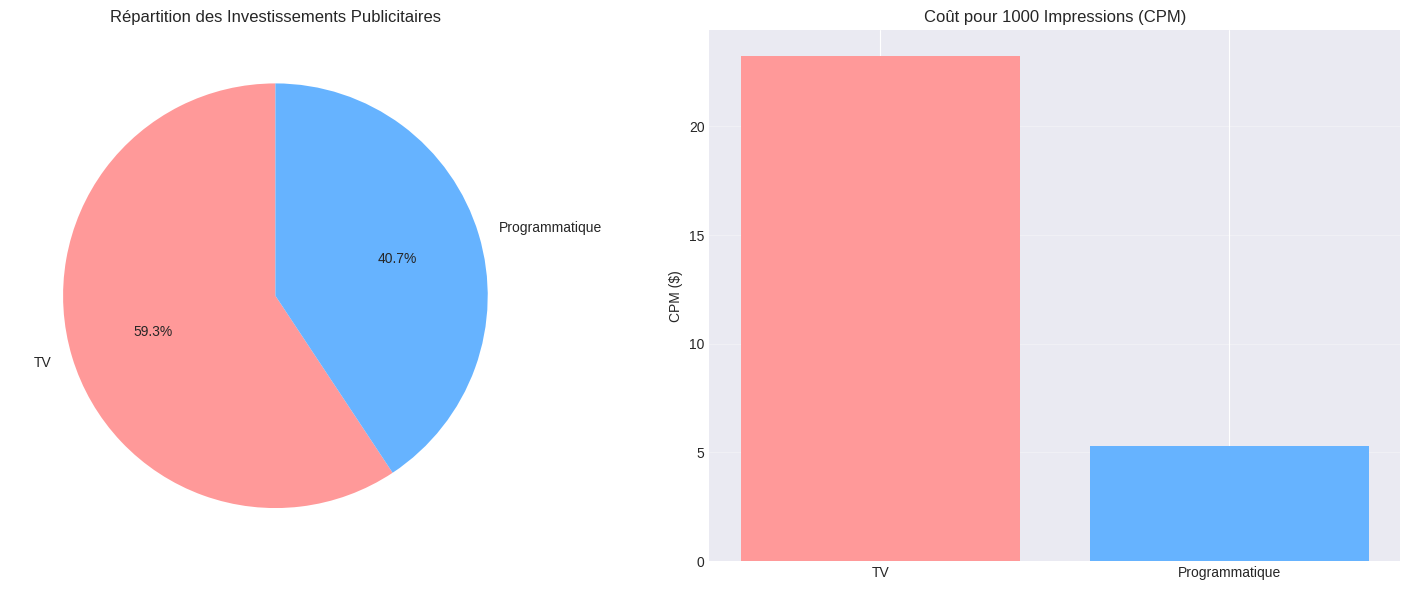

In [16]:
# Visualisation des investissements
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Répartition des investissements
investments = [tv_investment, prog_investment]
labels = ['TV', 'Programmatique']
colors = ['#ff9999', '#66b3ff']

axes[0].pie(investments, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Répartition des Investissements Publicitaires')

# Comparaison CPM
axes[1].bar(['TV', 'Programmatique'], [tv_cpm, prog_cpm], color=colors)
axes[1].set_ylabel('CPM ($)')
axes[1].set_title('Coût pour 1000 Impressions (CPM)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2 Analyse temporelle de la publicité


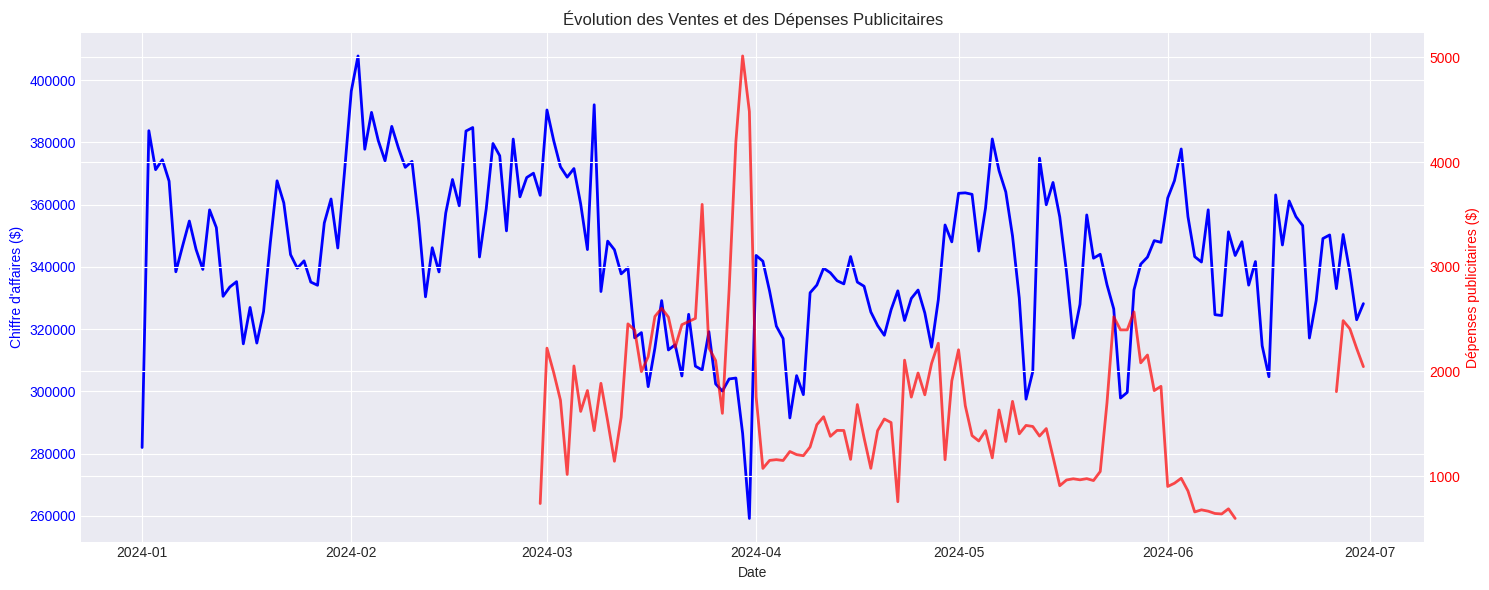

✓ Corrélation temporelle visualisée


In [17]:
# Agrégation quotidienne des dépenses publicitaires
df_tv = df_tv.with_columns(
    pl.col('timestamp_utc').cast(pl.Date).alias('date')
)
df_prog = df_prog.with_columns(
    pl.col('timestamp_utc').cast(pl.Date).alias('date')
)

tv_daily = df_tv.group_by('date').agg(pl.col('cost_dollar').sum().alias('tv_cost'))

prog_daily = df_prog.group_by('date').agg(pl.col('cost_dollar').sum().alias('prog_cost'))

# Merge avec les ventes
ad_sales_daily = daily_sales.join(tv_daily, on='date', how='outer',suffix='_tv')
ad_sales_daily = ad_sales_daily.join(prog_daily, on='date', how='outer',suffix='_prog')
ad_sales_daily = ad_sales_daily.with_columns(
    pl.col('tv_cost').fill_null(0),
    pl.col('prog_cost').fill_null(0),
    (pl.col('tv_cost') + pl.col('prog_cost')).alias('total_ad_cost')
)

# Visualisation
fig, ax1 = plt.subplots(figsize=(15, 6))
ad_sales_daily = ad_sales_daily.sort('date')

ax1.set_xlabel('Date')
ax1.set_ylabel('Chiffre d\'affaires ($)', color='blue')
ax1.plot(ad_sales_daily['date'], ad_sales_daily['revenue'], color='blue', linewidth=2, label='Ventes')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Dépenses publicitaires ($)', color='red')
ax2.plot(ad_sales_daily['date'], ad_sales_daily['total_ad_cost'], color='red', linewidth=2, alpha=0.7, label='Pub totale')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Évolution des Ventes et des Dépenses Publicitaires')
fig.tight_layout()
plt.show()

print("✓ Corrélation temporelle visualisée")


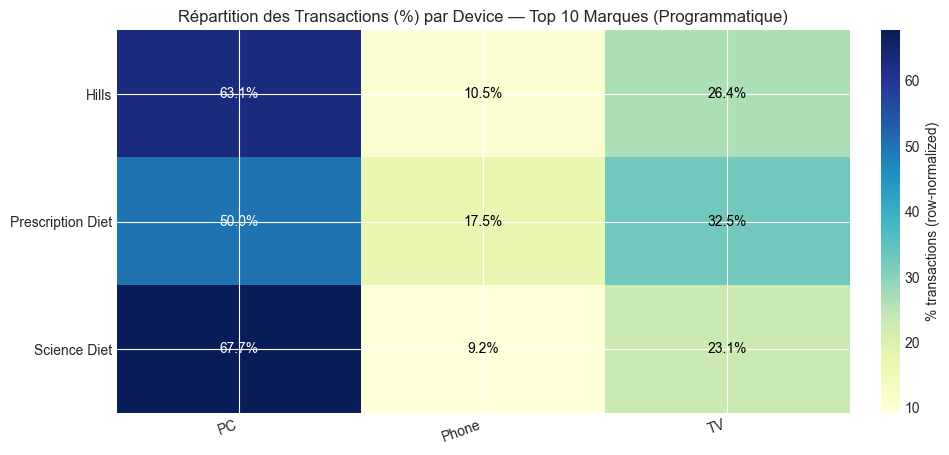

device_type,PC,Phone,TV
brand,,,
Hills,63.10,10.53,26.37
Prescription Diet,49.97,17.49,32.54
Science Diet,67.69,9.21,23.11


In [ ]:
# 0) Check colonnes
assert "device_type" in df_prog.columns, "df_prog doit contenir device_type"
assert "dsp_id" in df_mapping.columns, "df_mapping doit contenir dsp_id"

# 1) Joindre purchases -> dsp_id (1 dsp_id par customer) puis -> device_type via df_prog
map_prog = (df_mapping[["customer_id","dsp_id"]]
            .dropna(subset=["dsp_id"])
            .loc[~df_mapping["dsp_id"].isin(BAD_IDS)]
            .drop_duplicates("customer_id"))

p = df_purchases[["customer_id","brand","sales"]].copy()
p = p.merge(map_prog, on="customer_id", how="inner")

prog_dev = (df_prog[["dsp_id","device_type"]]
            .dropna(subset=["device_type","dsp_id"])
            .loc[~df_prog["dsp_id"].isin(BAD_IDS)]
            .copy())
prog_dev["device_type"] = prog_dev["device_type"].astype(str).str.strip()
prog_dev = prog_dev[~prog_dev["device_type"].isin({"unknown","Unknown","",None})]

# ❗ pour éviter de dupliquer si plusieurs lignes par dsp_id, on prend le device_type majoritaire
major_dev = (prog_dev.groupby(["dsp_id","device_type"]).size()
             .reset_index(name="n")
             .sort_values("n", ascending=False)
             .drop_duplicates("dsp_id")[["dsp_id","device_type"]])

p = p.merge(major_dev, on="dsp_id", how="inner")

# 2) Top marques (par CA) pour lisibilité
top_brands = (df_purchases.groupby("brand")["sales"].sum()
              .sort_values(ascending=False)
              .head(10).index)

pp = p[p["brand"].isin(top_brands)].copy()

# 3) Table marque x device : % de transactions
ct = pd.crosstab(pp["brand"], pp["device_type"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# 4) Heatmap
fig, ax = plt.subplots(figsize=(1.2*ct_pct.shape[1] + 6, 0.55*ct_pct.shape[0] + 3))
im = ax.imshow(ct_pct.values, aspect="auto", cmap=plt.get_cmap("YlGnBu"))

ax.set_title("Répartition des Transactions (%) par Device — Top 10 Marques (Programmatique)")
ax.set_yticks(range(ct_pct.shape[0])); ax.set_yticklabels(ct_pct.index)
ax.set_xticks(range(ct_pct.shape[1])); ax.set_xticklabels(ct_pct.columns, rotation=20, ha="right")

for i in range(ct_pct.shape[0]):
    for j in range(ct_pct.shape[1]):
        v = ct_pct.values[i, j]
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center", color=("white" if v > 40 else "black"))

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label("% transactions (row-normalized)")
plt.tight_layout()
plt.show()

display(ct_pct.round(2))


In [ ]:
TOP_N_BRANDS = 10

# 1) Top marques (par CA)
top_brands = (df_purchases.groupby("brand")["sales"].sum()
              .sort_values(ascending=False)
              .head(TOP_N_BRANDS).index.tolist())

p = df_purchases[df_purchases["brand"].isin(top_brands)][["customer_id","brand","sales"]].copy()

# Reach = buyers uniques par marque
reach = p.groupby("brand")["customer_id"].nunique().rename("reach")

# Conversions attribuées = nb d'achats attribués par marque (TV + Prog)
conv = pd.Series(0, index=top_brands, dtype=float)

if "m_tv" in globals() and len(m_tv) > 0:
    conv = conv.add(m_tv.groupby("brand")["sales"].size().reindex(top_brands).fillna(0), fill_value=0)

if "m_prog" in globals() and len(m_prog) > 0:
    conv = conv.add(m_prog.groupby("brand")["sales"].size().reindex(top_brands).fillna(0), fill_value=0)

conv = conv.rename("conversions_attributed")

# Impressions = nb d'expositions sur les acheteurs de la marque
# (join events sur customers qui ont acheté la marque)
buyers_by_brand = p.groupby("brand")["customer_id"].apply(lambda s: set(s.unique())).to_dict()

impr = {}
for b in top_brands:
    buyers = buyers_by_brand[b]
    impr[b] = int((events["customer_id"].isin(buyers)).sum())
impr = pd.Series(impr).rename("impressions_on_buyers")

brand_kpi = pd.concat([reach, impr, conv], axis=1).fillna(0)
brand_kpi["sales"] = p.groupby("brand")["sales"].sum()
brand_kpi["conv_rate_%"] = np.where(brand_kpi["reach"]>0, brand_kpi["conversions_attributed"]/brand_kpi["reach"]*100, np.nan)

display(brand_kpi.sort_values("sales", ascending=False).round(2))


,reach,impressions_on_buyers,conversions_attributed,sales,conv_rate_%
Science Diet,434444,840369,98853.0,52631975.20,22.75
Prescription Diet,46772,157595,9260.0,7947708.49,19.80
Hills,38689,74171,9103.0,1148559.34,23.53


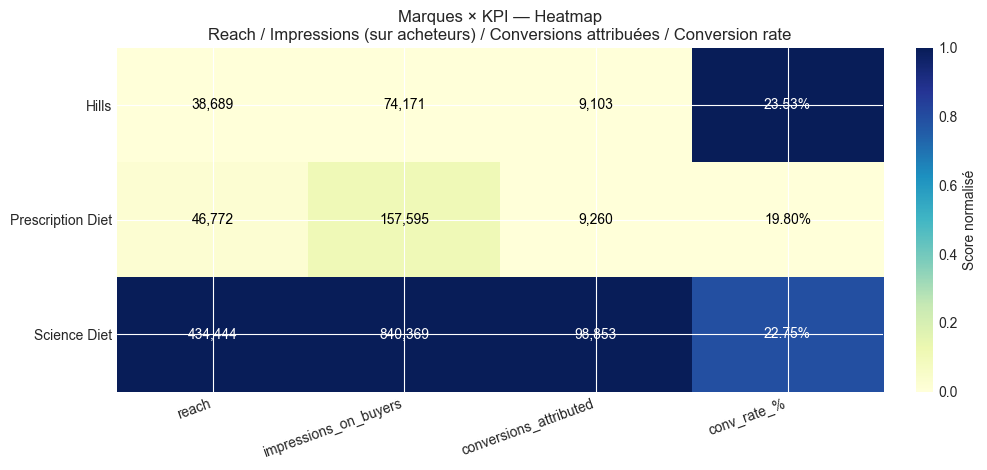

,reach,impressions_on_buyers,conversions_attributed,conv_rate_%
Hills,38689,74171,9103.0,23.53
Prescription Diet,46772,157595,9260.0,19.80
Science Diet,434444,840369,98853.0,22.75


In [ ]:
show_cols = ["reach", "impressions_on_buyers", "conversions_attributed", "conv_rate_%"]
X = brand_kpi[show_cols].copy()

# Normalisation 0-1 par KPI
Xn = (X - X.min()) / (X.max() - X.min()).replace(0, 1)

fig, ax = plt.subplots(figsize=(10, 0.6*len(Xn) + 3))
im = ax.imshow(Xn.values, aspect="auto", cmap=plt.get_cmap("YlGnBu"), vmin=0, vmax=1)

ax.set_title("Marques × KPI — Heatmap\nReach / Impressions (sur acheteurs) / Conversions attribuées / Conversion rate")
ax.set_yticks(range(len(Xn.index))); ax.set_yticklabels(Xn.index)
ax.set_xticks(range(len(show_cols))); ax.set_xticklabels(show_cols, rotation=20, ha="right")

# annotations (valeurs brutes)
for i, brand in enumerate(Xn.index):
    for j, c in enumerate(show_cols):
        raw = X.loc[brand, c]
        if c.endswith("%"):
            raw_s = f"{raw:.2f}%"
        elif c in ["reach", "impressions_on_buyers", "conversions_attributed"]:
            raw_s = f"{raw:,.0f}"
        else:
            raw_s = f"{raw:,.2f}"
        color = "white" if Xn.iloc[i, j] > 0.55 else "black"
        ax.text(j, i, raw_s, ha="center", va="center", color=color)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label("Score normalisé")
plt.tight_layout()
plt.show()

display(X.round(2))


### 4.3 Linking clients exposés à la publicité et achats


In [ ]:
# customers "matchables" (attention: pas forcément VRAIMENT exposés, juste mappables)
customers_with_tv = set(df_mapping.loc[df_mapping["device_id"].notna(), "customer_id"])
customers_with_prog = set(df_mapping.loc[df_mapping["dsp_id"].notna(), "customer_id"])

all_buyers = set(df_purchases["customer_id"])

buyers_with_tv = all_buyers & customers_with_tv
buyers_with_prog = all_buyers & customers_with_prog
buyers_with_both = buyers_with_tv & buyers_with_prog
buyers_no_ad = all_buyers - (customers_with_tv | customers_with_prog)

print(f"Clients avec TV identifiée: {len(customers_with_tv):,}")
print(f"Clients avec prog identifiée: {len(customers_with_prog):,}")
print(f"Total acheteurs: {len(all_buyers):,}\n")

def pct(x): 
    return 100.0 * x / len(all_buyers) if all_buyers else 0.0

print(f"Acheteurs exposés à la TV: {len(buyers_with_tv):,} ({pct(len(buyers_with_tv)):.1f}%)")
print(f"Acheteurs exposés au programmatique: {len(buyers_with_prog):,} ({pct(len(buyers_with_prog)):.1f}%)")
print(f"Acheteurs exposés aux deux: {len(buyers_with_both):,} ({pct(len(buyers_with_both)):.1f}%)")
print(f"Acheteurs sans expo pub identifiée: {len(buyers_no_ad):,} ({pct(len(buyers_no_ad)):.1f}%)")


Clients avec TV identifiée: 7,825,710
Clients avec prog identifiée: 7,825,711
Total acheteurs: 502,026

Acheteurs exposés à la TV: 502,025 (100.0%)
Acheteurs exposés au programmatique: 502,026 (100.0%)
Acheteurs exposés aux deux: 502,025 (100.0%)
Acheteurs sans expo pub identifiée: 0 (0.0%)



PERFORMANCE PAR SEGMENT D'EXPOSITION PUBLICITAIRE
           Total Sales  Avg Basket  Transactions  Unique Customers  \
segment                                                              
Both       61193480.15       43.37       1410888            502025   
Prog Only   1234469.03       43.43         28423                 1   

           Avg Sales per Customer  Avg Transactions per Customer  
segment                                                           
Both                       121.89                           2.81  
Prog Only              1234469.03                       28423.00  


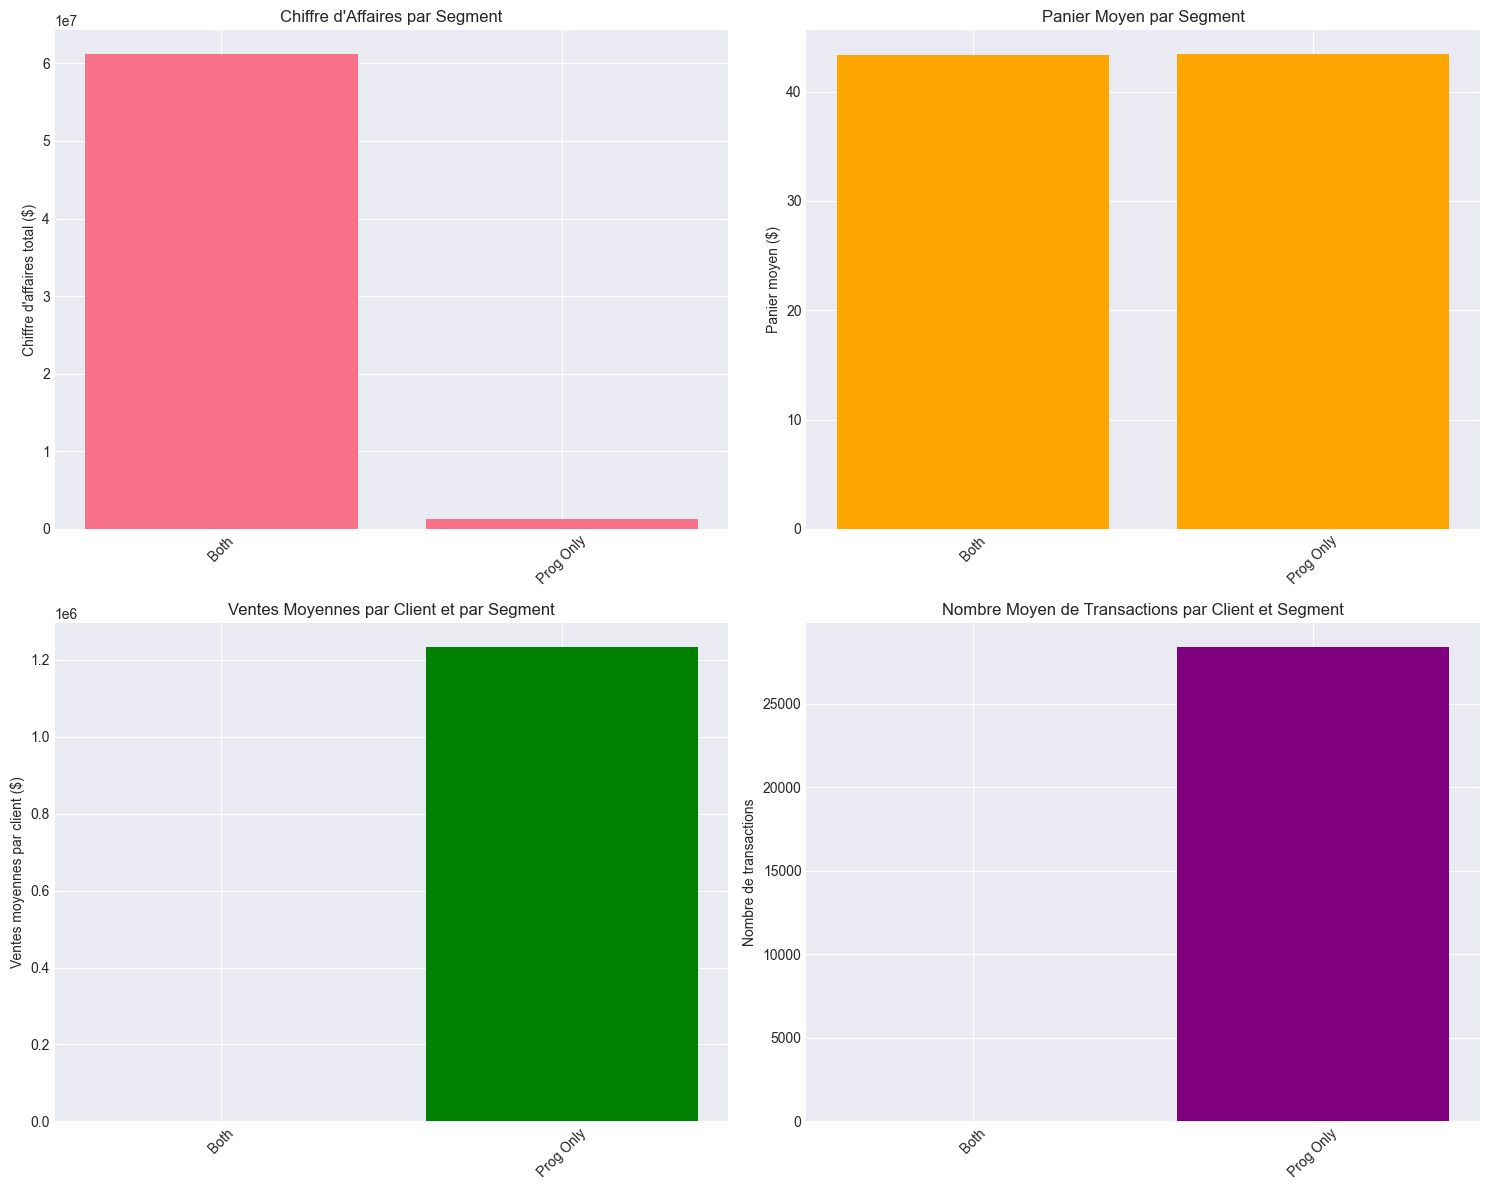

In [ ]:
# Création des segments
df_purchases['segment'] = 'No Ad'
df_purchases.loc[df_purchases['customer_id'].isin(buyers_with_tv), 'segment'] = 'TV Only'
df_purchases.loc[df_purchases['customer_id'].isin(buyers_with_prog), 'segment'] = 'Prog Only'
df_purchases.loc[df_purchases['customer_id'].isin(buyers_with_both), 'segment'] = 'Both'

# Performance par segment
segment_performance = df_purchases.groupby('segment').agg({
    'sales': ['sum', 'mean', 'count'],
    'customer_id': 'nunique'
}).round(2)

segment_performance.columns = ['Total Sales', 'Avg Basket', 'Transactions', 'Unique Customers']
segment_performance['Avg Sales per Customer'] = (segment_performance['Total Sales'] / segment_performance['Unique Customers']).round(2)
segment_performance['Avg Transactions per Customer'] = (segment_performance['Transactions'] / segment_performance['Unique Customers']).round(2)

print("\nPERFORMANCE PAR SEGMENT D'EXPOSITION PUBLICITAIRE")
print("=" * 80)
print(segment_performance)

# Visualisation
fig,axes = plt.subplots(2, 2, figsize=(15, 12))

# Chiffre d'affaires par segment
axes[0, 0].bar(segment_performance.index, segment_performance['Total Sales'])
axes[0, 0].set_ylabel('Chiffre d\'affaires total ($)')
axes[0, 0].set_title('Chiffre d\'Affaires par Segment')
axes[0, 0].tick_params(axis='x', rotation=45)

# Panier moyen par segment
axes[0, 1].bar(segment_performance.index, segment_performance['Avg Basket'], color='orange')
axes[0, 1].set_ylabel('Panier moyen ($)')
axes[0, 1].set_title('Panier Moyen par Segment')
axes[0, 1].tick_params(axis='x', rotation=45)

# Ventes moyennes par client
axes[1, 0].bar(segment_performance.index, segment_performance['Avg Sales per Customer'], color='green')
axes[1, 0].set_ylabel('Ventes moyennes par client ($)')
axes[1, 0].set_title('Ventes Moyennes par Client et par Segment')
axes[1, 0].tick_params(axis='x', rotation=45)

# Transactions moyennes par client
axes[1, 1].bar(segment_performance.index, segment_performance['Avg Transactions per Customer'], color='purple')
axes[1, 1].set_ylabel('Nombre de transactions')
axes[1, 1].set_title('Nombre Moyen de Transactions par Client et Segment')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 4.4 Analyse de l'effet temporel de la publicité (Attribution)


In [ ]:
print("ANALYSE D'ATTRIBUTION - LAST TOUCH (TV) - 7 jours (exclude 'unknown')")
print("=" * 80)

WINDOW_HOURS = 168
BAD_IDS = {"unknown", "UNKNOWN", "", "nan", "None", None}

# timestamps
df_purchases = df_purchases.copy()
df_tv = df_tv.copy()
df_mapping = df_mapping.copy()

df_purchases["timestamp_utc"] = pd.to_datetime(df_purchases["timestamp_utc"], errors="coerce")
df_tv["timestamp_utc"] = pd.to_datetime(df_tv["timestamp_utc"], errors="coerce")
df_purchases = df_purchases.dropna(subset=["timestamp_utc"])
df_tv = df_tv.dropna(subset=["timestamp_utc"])

# mapping customer -> device_id (clean)
map_one = (df_mapping[["customer_id", "device_id"]]
           .dropna(subset=["device_id"])
           .loc[~df_mapping["device_id"].isin(BAD_IDS)]
           .drop_duplicates("customer_id"))

# purchases mapped
p = (df_purchases.merge(map_one, on="customer_id", how="inner")
     .rename(columns={"timestamp_utc": "ts_purchase"}))

# tv exposures (clean)
t = (df_tv[["device_id", "timestamp_utc", "cost_dollar"]]
     .rename(columns={"timestamp_utc": "ts_ad"}))
t = t.loc[~t["device_id"].isin(BAD_IDS)]

# merge + window
m = p.merge(t, on="device_id", how="inner")
m["dt_h"] = (m["ts_purchase"] - m["ts_ad"]).dt.total_seconds() / 3600
m = m[m["dt_h"].between(0, WINDOW_HOURS, inclusive="both")]

# last touch: dernière expo avant achat
m = (m.sort_values("ts_ad")
     .groupby(["customer_id", "ts_purchase"], as_index=False)
     .tail(1))

print(f"Achats attribués TV (last-touch, 7j): {len(m):,}")
print(f"Sales attribuées TV (last-touch): {m['sales'].sum():,.2f} $")
print(f"Acheteurs uniques attribués TV: {m['customer_id'].nunique():,}")


ANALYSE D'ATTRIBUTION - LAST TOUCH (TV) - 7 jours (exclude 'unknown')
Achats attribués TV (last-touch, 7j): 8,108
Sales attribuées TV (last-touch): 352,100.96 $
Acheteurs uniques attribués TV: 6,816


In [ ]:
print("ANALYSE D'ATTRIBUTION - LAST TOUCH (PROGRAMMATIQUE) - 7 jours (exclude 'unknown')")
print("=" * 80)

WINDOW_HOURS = 168
BAD_IDS = {"unknown", "UNKNOWN", "", "nan", "None", None}

# --- timestamps ---
df_purchases = df_purchases.copy()
df_prog = df_prog.copy()
df_mapping = df_mapping.copy()

df_purchases["timestamp_utc"] = pd.to_datetime(df_purchases["timestamp_utc"], errors="coerce")
df_prog["timestamp_utc"] = pd.to_datetime(df_prog["timestamp_utc"], errors="coerce")
df_purchases = df_purchases.dropna(subset=["timestamp_utc"])
df_prog = df_prog.dropna(subset=["timestamp_utc"])

# --- mapping customer -> dsp_id (clean) ---
map_prog = (df_mapping[["customer_id", "dsp_id"]]
            .dropna(subset=["dsp_id"])
            .loc[~df_mapping["dsp_id"].isin(BAD_IDS)]
            .drop_duplicates("customer_id"))

# purchases mapped
p = (df_purchases.merge(map_prog, on="customer_id", how="inner")
     .rename(columns={"timestamp_utc": "ts_purchase"}))

# programmatic exposures (clean)
cols_prog = ["dsp_id", "timestamp_utc", "cost_dollar"]
if "campaign_name" in df_prog.columns:
    cols_prog.append("campaign_name")

t = (df_prog[cols_prog]
     .rename(columns={"timestamp_utc": "ts_ad"}))
t = t.loc[~t["dsp_id"].isin(BAD_IDS)]

# merge + window
m = p.merge(t, on="dsp_id", how="inner")
m["dt_h"] = (m["ts_purchase"] - m["ts_ad"]).dt.total_seconds() / 3600
m = m[m["dt_h"].between(0, WINDOW_HOURS, inclusive="both")]

# last touch: dernière expo prog avant achat (1 ligne par achat)
m = (m.sort_values("ts_ad")
     .groupby(["customer_id", "ts_purchase"], as_index=False)
     .tail(1))

print(f"Achats attribués Programmatique (last-touch, 7j): {len(m):,}")
print(f"Sales attribuées Programmatique (last-touch): {m['sales'].sum():,.2f} $")
print(f"Acheteurs uniques attribués Programmatique: {m['customer_id'].nunique():,}")

# --- Bonus: top campagnes par sales attribuées (si dispo) ---
if "campaign_name" in m.columns:
    top_campaigns = (m.groupby("campaign_name")
                     .agg(attributed_sales=("sales","sum"),
                          purchases=("sales","size"),
                          buyers=("customer_id","nunique"),
                          spend=("cost_dollar","sum"))
                     .sort_values("attributed_sales", ascending=False)
                     .head(10))
    print("\nTop 10 campagnes (sales attribuées, last-touch):")
    display(top_campaigns)


ANALYSE D'ATTRIBUTION - LAST TOUCH (PROGRAMMATIQUE) - 7 jours (exclude 'unknown')
Achats attribués Programmatique (last-touch, 7j): 109,859
Sales attribuées Programmatique (last-touch): 4,743,423.19 $
Acheteurs uniques attribués Programmatique: 83,014

Top 10 campagnes (sales attribuées, last-touch):


,attributed_sales,purchases,buyers,spend
campaign_name,,,,
Retargeting,4264262.31,98390,74806,1969.082678
Contextual,479160.88,11469,9118,70.378920


#### 4.4.1 Vérification et Debug

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WINDOW_HOURS = 7 * 24
BAD_IDS = {"unknown", "UNKNOWN", "", "nan", "None", None}



PERFORMANCE PAR SEGMENT D'EXPOSITION PUBLICITAIRE
           Total_Sales  Avg_Basket  Transactions  Unique_Customers  \
segment                                                              
Both       61193480.15       43.37       1410888            502025   
Prog Only   1234469.03       43.43         28423                 1   

           Avg Sales per Customer  Avg Transactions per Customer  
segment                                                           
Both                       121.89                           2.81  
Prog Only              1234469.03                       28423.00  


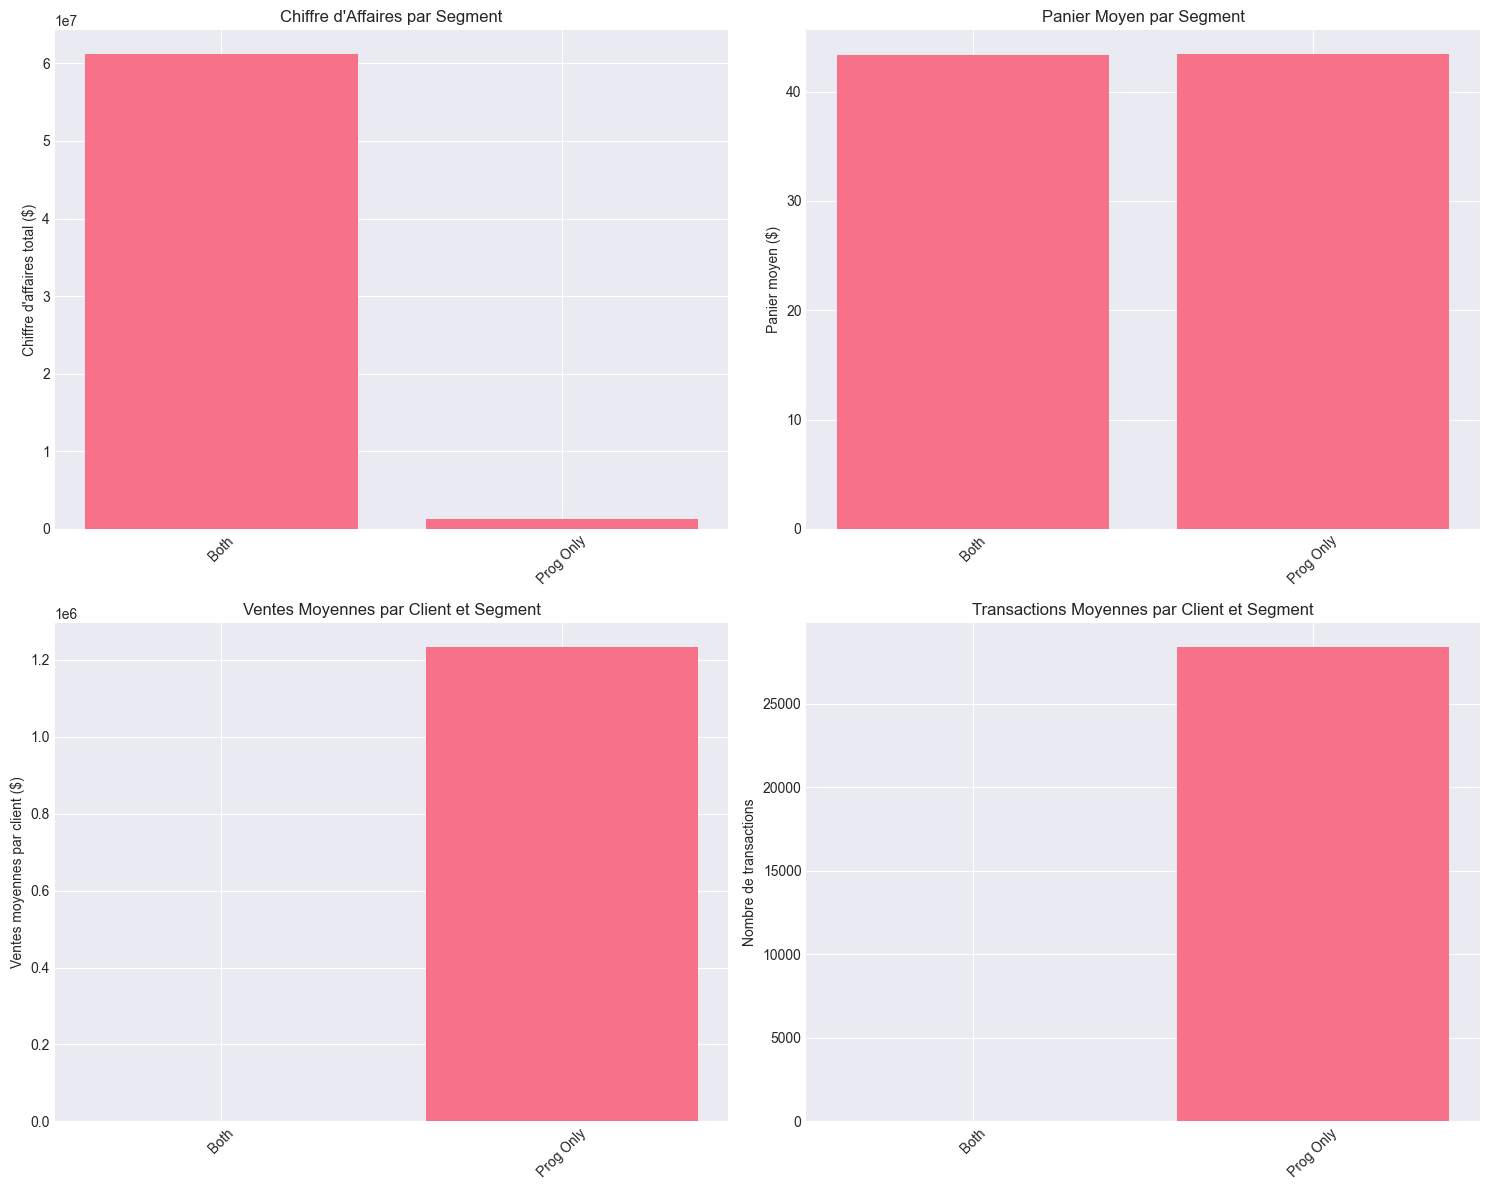

In [ ]:
# --- Création des segments (exclusive, correct) ---
tv = df_purchases["customer_id"].isin(buyers_with_tv)
pg = df_purchases["customer_id"].isin(buyers_with_prog)

df_purchases = df_purchases.copy()
df_purchases["segment"] = np.select(
    [tv & pg, tv & ~pg, ~tv & pg],
    ["Both", "TV Only", "Prog Only"],
    default="No Ad"
)

# --- Performance par segment ---
segment_performance = (
    df_purchases.groupby("segment")
    .agg(
        Total_Sales=("sales", "sum"),
        Avg_Basket=("sales", "mean"),          # moyenne par transaction
        Transactions=("sales", "size"),
        Unique_Customers=("customer_id", "nunique"),
    )
    .round(2)
)

segment_performance["Avg Sales per Customer"] = (
    segment_performance["Total_Sales"] / segment_performance["Unique_Customers"]
).round(2)

segment_performance["Avg Transactions per Customer"] = (
    segment_performance["Transactions"] / segment_performance["Unique_Customers"]
).round(2)

segment_performance = segment_performance.sort_values("Total_Sales", ascending=False)

print("\nPERFORMANCE PAR SEGMENT D'EXPOSITION PUBLICITAIRE")
print("=" * 80)
print(segment_performance)

# --- Visualisation ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].bar(segment_performance.index, segment_performance["Total_Sales"])
axes[0, 0].set_ylabel("Chiffre d'affaires total ($)")
axes[0, 0].set_title("Chiffre d'Affaires par Segment")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(segment_performance.index, segment_performance["Avg_Basket"])
axes[0, 1].set_ylabel("Panier moyen ($)")
axes[0, 1].set_title("Panier Moyen par Segment")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(segment_performance.index, segment_performance["Avg Sales per Customer"])
axes[1, 0].set_ylabel("Ventes moyennes par client ($)")
axes[1, 0].set_title("Ventes Moyennes par Client et Segment")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].bar(segment_performance.index, segment_performance["Avg Transactions per Customer"])
axes[1, 1].set_ylabel("Nombre de transactions")
axes[1, 1].set_title("Transactions Moyennes par Client et Segment")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
print("ANALYSE D'ATTRIBUTION - DEBUG (TV)")
print("="*80)

# timestamps
df_purchases["timestamp_utc"] = pd.to_datetime(df_purchases["timestamp_utc"], errors="coerce")
df_tv["timestamp_utc"] = pd.to_datetime(df_tv["timestamp_utc"], errors="coerce")
df_purchases = df_purchases.dropna(subset=["timestamp_utc"])
df_tv = df_tv.dropna(subset=["timestamp_utc"])

# mapping customer -> device_id (clean + one row per customer)
map_one = (df_mapping[["customer_id","device_id"]]
           .dropna(subset=["device_id"])
           .loc[~df_mapping["device_id"].isin(BAD_IDS)]
           .drop_duplicates("customer_id"))

print("map_one rows:", len(map_one))

p = (df_purchases.merge(map_one, on="customer_id", how="inner")
     .rename(columns={"timestamp_utc":"ts_purchase"}))
print("purchases mapped rows:", len(p))

top_p = p["device_id"].value_counts().head(3)
top_t = df_tv.loc[~df_tv["device_id"].isin(BAD_IDS), "device_id"].value_counts().head(3)
print("\nTop purchases per device_id:\n", top_p)
print("\nTop tv exposures per device_id:\n", top_t)

approx_pairs = int(top_p.iloc[0]) * int(top_t.iloc[0]) if len(top_p) and len(top_t) else 0
print("\nrough worst-case pairs (top device):", f"{approx_pairs:,}")

if approx_pairs > 5_000_000:
    print("[!] Merge risque d'exploser -> utiliser LAST-TOUCH (cellule suivante)")
else:
    print("[OK] Merge probable gérable")


ANALYSE D'ATTRIBUTION - DEBUG (TV)
map_one rows: 7593088
purchases mapped rows: 1369528

Top purchases per device_id:
 device_id
ctvA4p8jruSD    2013
ctvUgOASjPTK    1259
ctvpiV7WC43G     205
Name: count, dtype: int64

Top tv exposures per device_id:
 device_id
ctvvlQDkZyTX    234
ctvZ1y2PnMlM    203
ctv6dVPrLKcl    202
Name: count, dtype: int64

rough worst-case pairs (top device): 471,042
[OK] Merge probable gérable


In [ ]:
print("ANALYSE D'ATTRIBUTION - LAST TOUCH (TV) - 7 jours")
print("=" * 80)

# timestamps
df_purchases["timestamp_utc"] = pd.to_datetime(df_purchases["timestamp_utc"], errors="coerce")
df_tv["timestamp_utc"] = pd.to_datetime(df_tv["timestamp_utc"], errors="coerce")
purch = df_purchases.dropna(subset=["timestamp_utc"]).copy()
tv = df_tv.dropna(subset=["timestamp_utc"]).copy()

# mapping clean
map_tv = (df_mapping[["customer_id","device_id"]]
          .dropna(subset=["device_id"])
          .loc[~df_mapping["device_id"].isin(BAD_IDS)]
          .drop_duplicates("customer_id"))

# purchases mapped
p = (purch.merge(map_tv, on="customer_id", how="inner")
     .rename(columns={"timestamp_utc":"ts_purchase"}))

# tv exposures clean
t = (tv[["device_id","timestamp_utc","cost_dollar"]]
     .rename(columns={"timestamp_utc":"ts_ad"}))
t = t.loc[~t["device_id"].isin(BAD_IDS)]

# merge + window
m_tv = p.merge(t, on="device_id", how="inner")
m_tv["dt_h"] = (m_tv["ts_purchase"] - m_tv["ts_ad"]).dt.total_seconds() / 3600
m_tv = m_tv[m_tv["dt_h"].between(0, WINDOW_HOURS, inclusive="both")].copy()

# last-touch: dernière expo avant achat (1 ligne par achat)
m_tv = (m_tv.sort_values("ts_ad")
        .groupby(["customer_id","ts_purchase"], as_index=False)
        .tail(1)
        .copy())

m_tv["time_diff_hours"] = m_tv["dt_h"]

print(f"Achats attribués TV (last-touch, 7j): {len(m_tv):,}")
print(f"Sales attribuées TV (last-touch): {m_tv['sales'].sum():,.2f} $")
print(f"Acheteurs uniques attribués TV: {m_tv['customer_id'].nunique():,}")


ANALYSE D'ATTRIBUTION - LAST TOUCH (TV) - 7 jours
Achats attribués TV (last-touch, 7j): 8,108
Sales attribuées TV (last-touch): 352,100.96 $
Acheteurs uniques attribués TV: 6,816


In [ ]:
print("ANALYSE D'ATTRIBUTION - LAST TOUCH (PROGRAMMATIQUE) - 7 jours")
print("=" * 80)

# timestamps
df_purchases["timestamp_utc"] = pd.to_datetime(df_purchases["timestamp_utc"], errors="coerce")
df_prog["timestamp_utc"] = pd.to_datetime(df_prog["timestamp_utc"], errors="coerce")
purch = df_purchases.dropna(subset=["timestamp_utc"]).copy()
prog = df_prog.dropna(subset=["timestamp_utc"]).copy()

# mapping clean
map_prog = (df_mapping[["customer_id","dsp_id"]]
            .dropna(subset=["dsp_id"])
            .loc[~df_mapping["dsp_id"].isin(BAD_IDS)]
            .drop_duplicates("customer_id"))

# purchases mapped
p = (purch.merge(map_prog, on="customer_id", how="inner")
     .rename(columns={"timestamp_utc":"ts_purchase"}))

# prog exposures clean
cols = ["dsp_id","timestamp_utc","cost_dollar"]
if "campaign_name" in prog.columns:
    cols.append("campaign_name")

t = (prog[cols]
     .rename(columns={"timestamp_utc":"ts_ad"}))
t = t.loc[~t["dsp_id"].isin(BAD_IDS)]

# merge + window
m_prog = p.merge(t, on="dsp_id", how="inner")
m_prog["dt_h"] = (m_prog["ts_purchase"] - m_prog["ts_ad"]).dt.total_seconds() / 3600
m_prog = m_prog[m_prog["dt_h"].between(0, WINDOW_HOURS, inclusive="both")].copy()

# last-touch
m_prog = (m_prog.sort_values("ts_ad")
          .groupby(["customer_id","ts_purchase"], as_index=False)
          .tail(1)
          .copy())

m_prog["time_diff_hours"] = m_prog["dt_h"]

print(f"Achats attribués Prog (last-touch, 7j): {len(m_prog):,}")
print(f"Sales attribuées Prog (last-touch): {m_prog['sales'].sum():,.2f} $")
print(f"Acheteurs uniques attribués Prog: {m_prog['customer_id'].nunique():,}")

if "campaign_name" in m_prog.columns:
    top_campaigns = (m_prog.groupby("campaign_name")
                     .agg(attributed_sales=("sales","sum"),
                          purchases=("sales","size"),
                          buyers=("customer_id","nunique"),
                          spend=("cost_dollar","sum"))
                     .sort_values("attributed_sales", ascending=False)
                     .head(10))
    display(top_campaigns)


ANALYSE D'ATTRIBUTION - LAST TOUCH (PROGRAMMATIQUE) - 7 jours
Achats attribués Prog (last-touch, 7j): 109,859
Sales attribuées Prog (last-touch): 4,743,423.19 $
Acheteurs uniques attribués Prog: 83,014


,attributed_sales,purchases,buyers,spend
campaign_name,,,,
Retargeting,4264262.31,98390,74806,1969.082678
Contextual,479160.88,11469,9118,70.378920


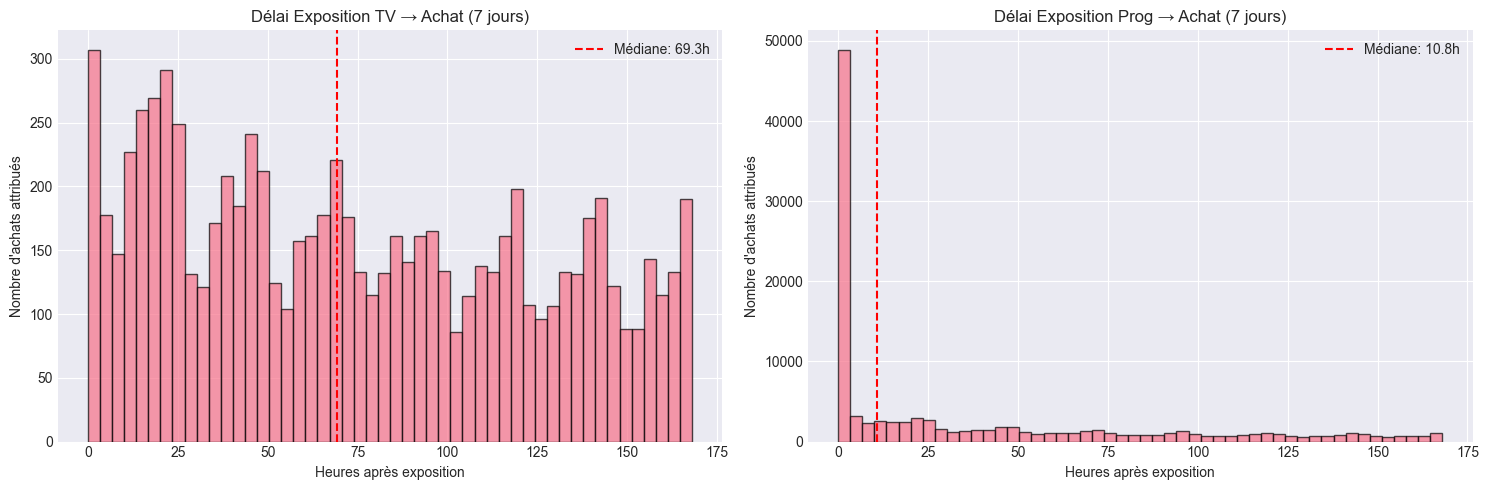

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TV
if "m_tv" in globals() and len(m_tv) > 0:
    axes[0].hist(m_tv["time_diff_hours"].dropna(), bins=50, edgecolor="black", alpha=0.7)
    med = m_tv["time_diff_hours"].median()
    axes[0].axvline(med, color="red", linestyle="--", label=f"Médiane: {med:.1f}h")
    axes[0].set_title("Délai Exposition TV → Achat (7 jours)")
    axes[0].set_xlabel("Heures après exposition")
    axes[0].set_ylabel("Nombre d'achats attribués")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Aucune donnée TV (m_tv absent/vide)", ha="center", va="center")
    axes[0].set_axis_off()

# Programmatique
if "m_prog" in globals() and len(m_prog) > 0:
    axes[1].hist(m_prog["time_diff_hours"].dropna(), bins=50, edgecolor="black", alpha=0.7)
    med = m_prog["time_diff_hours"].median()
    axes[1].axvline(med, color="red", linestyle="--", label=f"Médiane: {med:.1f}h")
    axes[1].set_title("Délai Exposition Prog → Achat (7 jours)")
    axes[1].set_xlabel("Heures après exposition")
    axes[1].set_ylabel("Nombre d'achats attribués")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Aucune donnée Prog (m_prog absent/vide)", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


#### 4.4.2 Visualisation avec Tendance

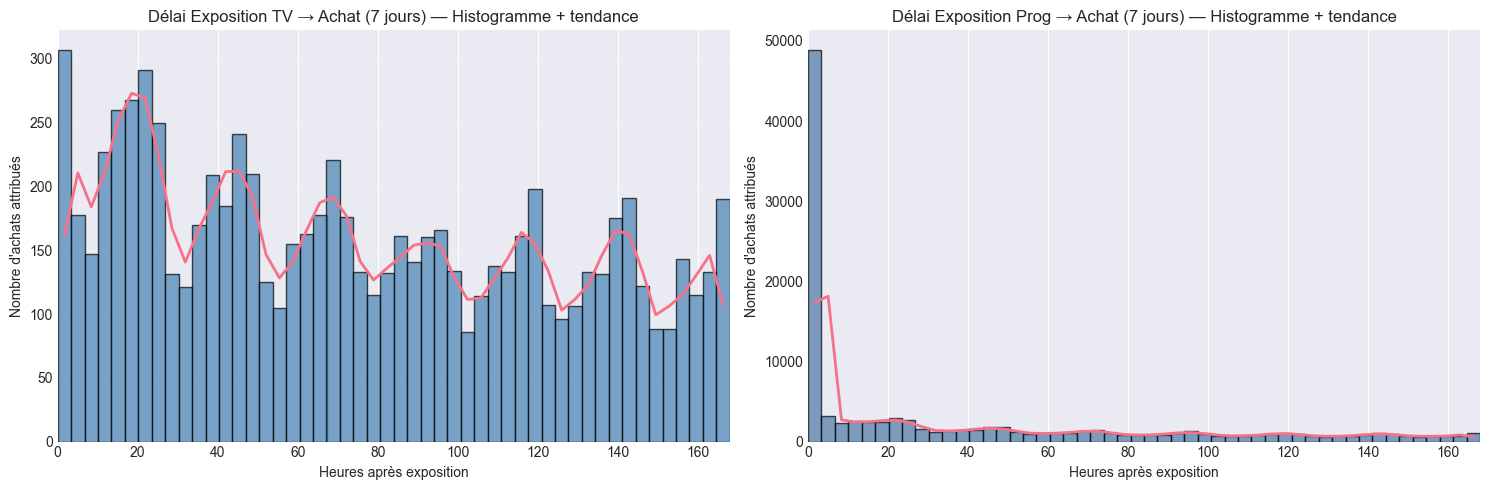

In [ ]:
def hist_with_trend(ax, x, bins=50, title="", bar_color=None):
    x = x.dropna()
    if len(x) == 0:
        ax.text(0.5, 0.5, "Aucune donnée", ha="center", va="center")
        ax.set_axis_off()
        return

    counts, edges = np.histogram(x.values, bins=bins, range=(0, 168))
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]

    ax.bar(
        centers,
        counts,
        width=width,
        edgecolor="black",
        alpha=0.7,
        color=bar_color  # <- couleur des barres
    )

    window = max(3, bins // 20)
    kernel = np.ones(window) / window
    smooth = np.convolve(counts, kernel, mode="same")
    ax.plot(centers, smooth, linewidth=2)  # garde la couleur par défaut

    ax.set_title(title)
    ax.set_xlabel("Heures après exposition")
    ax.set_ylabel("Nombre d'achats attribués")
    ax.set_xlim(0, 168)
    ax.grid(axis="y", alpha=0.25)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TV — change ici la couleur des barres (ex: 'steelblue', '#4C78A8', etc.)
if "m_tv" in globals() and len(m_tv) > 0:
    hist_with_trend(
        axes[0],
        m_tv["time_diff_hours"],
        bins=50,
        title="Délai Exposition TV → Achat (7 jours) — Histogramme + tendance",
        bar_color="steelblue"
    )
else:
    axes[0].text(0.5, 0.5, "Aucune donnée TV (m_tv absent/vide)", ha="center", va="center")
    axes[0].set_axis_off()

# Programmatique — change ici la couleur des barres
if "m_prog" in globals() and len(m_prog) > 0:
    hist_with_trend(
        axes[1],
        m_prog["time_diff_hours"],
        bins=50,
        title="Délai Exposition Prog → Achat (7 jours) — Histogramme + tendance",
        bar_color="#4C78A8"
    )
else:
    axes[1].text(0.5, 0.5, "Aucune donnée Prog (m_prog absent/vide)", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


### 4.5 ROI (Return on Investment) de la publicité


In [ ]:
total_sales = df_purchases["sales"].sum()
total_tx = len(df_purchases)
total_buyers = df_purchases["customer_id"].nunique()

attr_sales_prog = m_prog["sales"].sum()
attr_tx_prog = len(m_prog)
attr_buyers_prog = m_prog["customer_id"].nunique()

print("TOTAL SALES:", f"{total_sales:,.2f}")
print("ATTR SALES PROG:", f"{attr_sales_prog:,.2f}", f"({100*attr_sales_prog/total_sales:.1f}%)")
print("TOTAL TX:", total_tx, "| ATTR TX PROG:", attr_tx_prog, f"({100*attr_tx_prog/total_tx:.1f}%)")
print("TOTAL BUYERS:", total_buyers, "| ATTR BUYERS PROG:", attr_buyers_prog, f"({100*attr_buyers_prog/total_buyers:.1f}%)")


TOTAL SALES: 62,427,949.18
ATTR SALES PROG: 4,743,423.19 (7.6%)
TOTAL TX: 1439311 | ATTR TX PROG: 109859 (7.6%)
TOTAL BUYERS: 502026 | ATTR BUYERS PROG: 83014 (16.5%)


CALCUL DU ROI / ROAS PUBLICITAIRE (Last-touch, fenêtre 7 jours)

TV:
  - Investissement (total période): 135,510.61 $
  - Ventes attribuées (last-touch, 7j): 352,100.96 $
  - ROI: 159.83%
  - ROAS: 2.60x

Programmatique:
  - Investissement (total période): 92,973.13 $
  - Ventes attribuées (last-touch, 7j): 4,743,423.19 $
  - ROI: 5,001.93%
  - ROAS: 51.02x


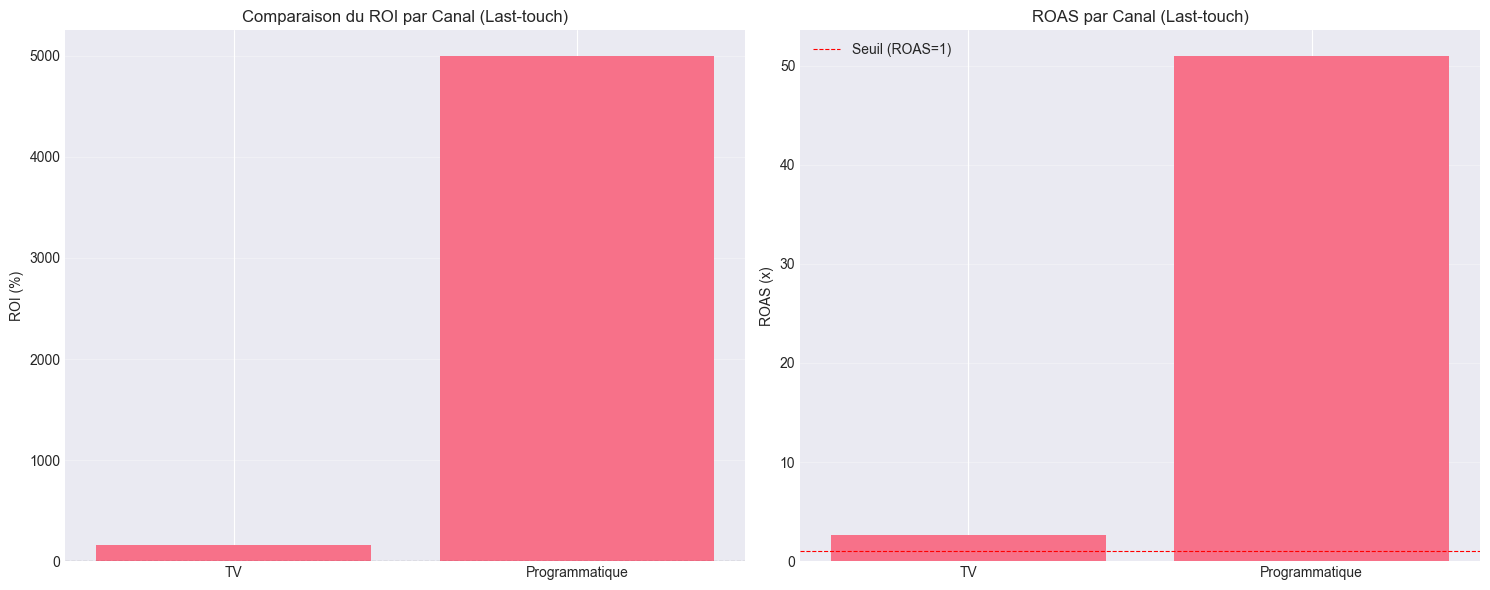

In [ ]:
print("CALCUL DU ROI / ROAS PUBLICITAIRE (Last-touch, fenêtre 7 jours)")
print("=" * 80)

# --- 0) Vérifier que les bons DF existent ---
if "m_tv" not in globals():
    print("⚠️ m_tv absent -> TV attribuée mise à 0")
if "m_prog" not in globals():
    print("⚠️ m_prog absent -> Prog attribuée mise à 0")

# --- 1) Ventes attribuées (last-touch) ---
tv_attributed_sales = float(m_tv["sales"].sum()) if "m_tv" in globals() and len(m_tv) > 0 else 0.0
prog_attributed_sales = float(m_prog["sales"].sum()) if "m_prog" in globals() and len(m_prog) > 0 else 0.0

# --- 2) Investissements (si variables non définies, on les calcule) ---
# (coût total des expositions — à mentionner en limite : "spend total période, pas forcément limité aux users convertis")
if "tv_investment" not in globals():
    tv_investment = float(df_tv.loc[~df_tv["device_id"].isin(BAD_IDS), "cost_dollar"].sum()) if "df_tv" in globals() else float(df_tv.loc[~df_tv["device_id"].isin(BAD_IDS), "cost_dollar"].sum())
if "prog_investment" not in globals():
    prog_investment = float(df_prog.loc[~df_prog["dsp_id"].isin(BAD_IDS), "cost_dollar"].sum())

tv_investment = float(tv_investment) if tv_investment is not None else 0.0
prog_investment = float(prog_investment) if prog_investment is not None else 0.0

# --- 3) ROI & ROAS ---
def safe_div(a, b):
    return a / b if b and b > 0 else np.nan

roas_tv = safe_div(tv_attributed_sales, tv_investment)
roas_prog = safe_div(prog_attributed_sales, prog_investment)

roi_tv = (roas_tv - 1.0) * 100 if not np.isnan(roas_tv) else np.nan
roi_prog = (roas_prog - 1.0) * 100 if not np.isnan(roas_prog) else np.nan

print(f"\nTV:")
print(f"  - Investissement (total période): {tv_investment:,.2f} $")
print(f"  - Ventes attribuées (last-touch, 7j): {tv_attributed_sales:,.2f} $")
print(f"  - ROI: {roi_tv:,.2f}%" if not np.isnan(roi_tv) else "  - ROI: N/A")
print(f"  - ROAS: {roas_tv:.2f}x" if not np.isnan(roas_tv) else "  - ROAS: N/A")

print(f"\nProgrammatique:")
print(f"  - Investissement (total période): {prog_investment:,.2f} $")
print(f"  - Ventes attribuées (last-touch, 7j): {prog_attributed_sales:,.2f} $")
print(f"  - ROI: {roi_prog:,.2f}%" if not np.isnan(roi_prog) else "  - ROI: N/A")
print(f"  - ROAS: {roas_prog:.2f}x" if not np.isnan(roas_prog) else "  - ROAS: N/A")

# --- 4) Visualisation ---
channels = ["TV", "Programmatique"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROI
axes[0].bar(channels, [0 if np.isnan(roi_tv) else roi_tv, 0 if np.isnan(roi_prog) else roi_prog])
axes[0].set_ylabel("ROI (%)")
axes[0].set_title("Comparaison du ROI par Canal (Last-touch)")
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=0.8)
axes[0].grid(axis="y", alpha=0.3)

# ROAS
axes[1].bar(channels, [0 if np.isnan(roas_tv) else roas_tv, 0 if np.isnan(roas_prog) else roas_prog])
axes[1].set_ylabel("ROAS (x)")
axes[1].set_title("ROAS par Canal (Last-touch)")
axes[1].axhline(y=1, color="red", linestyle="--", linewidth=0.8, label="Seuil (ROAS=1)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4.6 Analyse par campagne (Programmatique)



ROI PAR CAMPAGNE — PROGRAMMATIQUE (Last-touch, fenêtre 7 jours)


,campaign,attributed_sales,cost,attributed_purchases,unique_buyers,roi_pct,sales_per_buyer,cost_per_purchase
0,Contextual,479160.88,70.378920,11469,9118,680730.114520,52.551095,0.006136
1,Retargeting,4264262.31,1969.082678,98390,74806,216460.856396,57.004282,0.020013


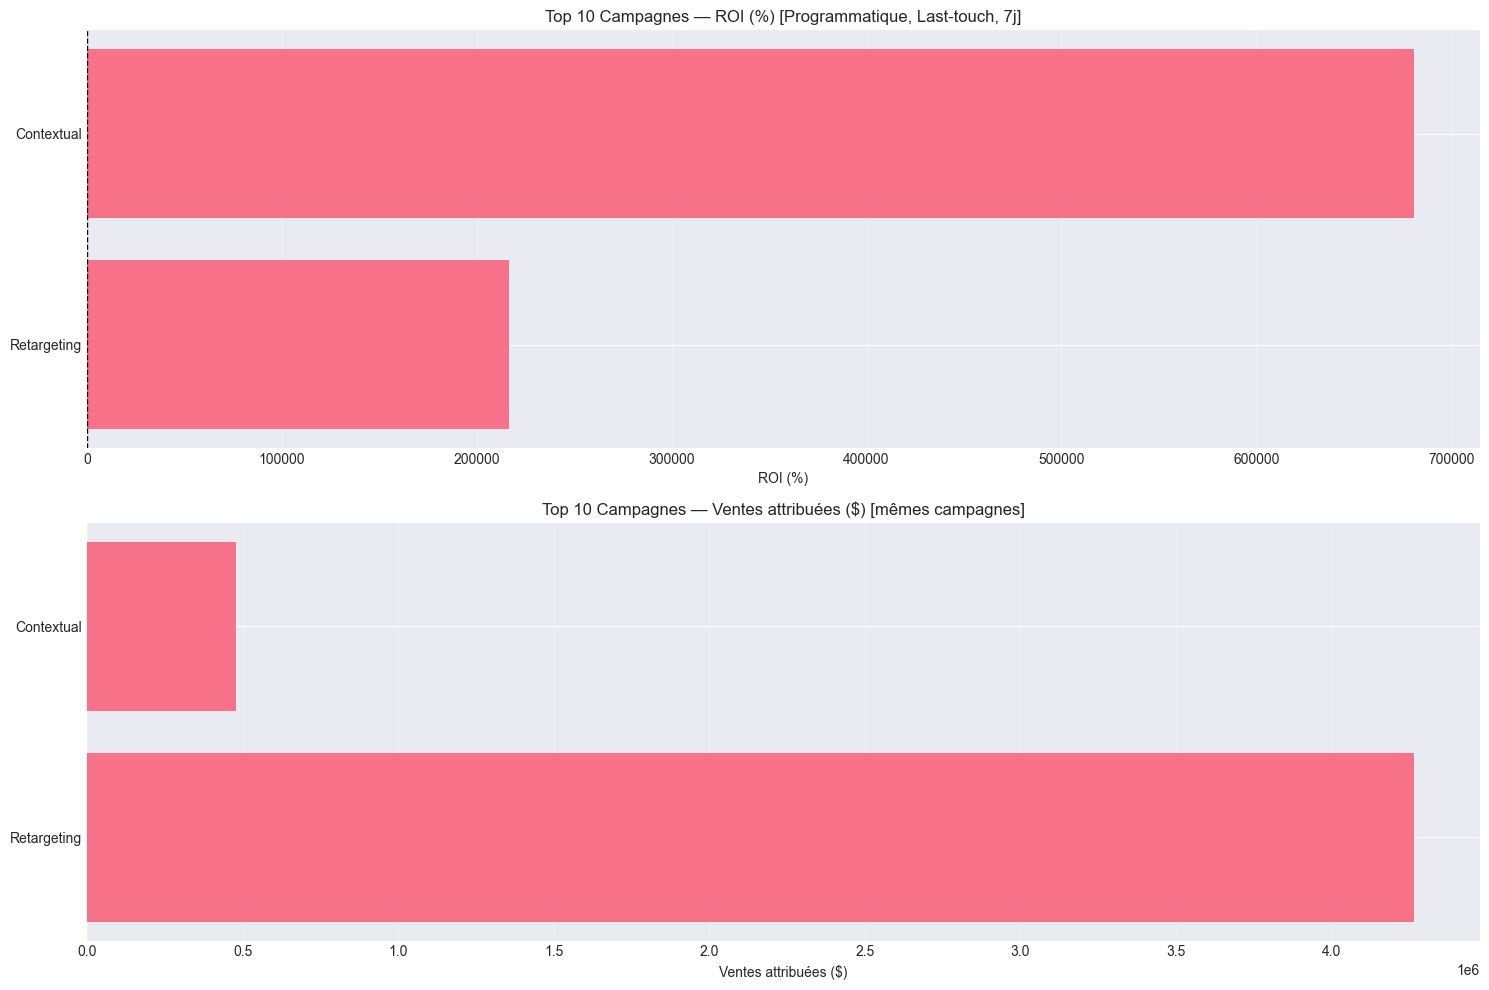

In [ ]:
# Attribution Programmatique — ROI par Campagne (Last-touch, 7 jours)
# ROI (%) = (Ventes attribuées - Coût) / Coût * 100

if "m_prog" in globals() and len(m_prog) > 0 and "campaign_name" in m_prog.columns:

    campaign_perf = (
        m_prog.groupby("campaign_name")
        .agg(
            attributed_sales=("sales", "sum"),
            cost=("cost_dollar", "sum"),
            attributed_purchases=("sales", "size"),     # nb d'achats attribués (last-touch)
            unique_buyers=("customer_id", "nunique"),
        )
        .reset_index()
        .rename(columns={"campaign_name": "campaign"})
    )

    # ROI (%) — sécurisé contre division par 0
    campaign_perf["roi_pct"] = np.where(
        campaign_perf["cost"] > 0,
        (campaign_perf["attributed_sales"] - campaign_perf["cost"]) / campaign_perf["cost"] * 100,
        np.nan
    )

    # (Optionnel mais utile) CA par acheteur attribué / CPA attribué
    campaign_perf["sales_per_buyer"] = np.where(
        campaign_perf["unique_buyers"] > 0,
        campaign_perf["attributed_sales"] / campaign_perf["unique_buyers"],
        np.nan
    )
    campaign_perf["cost_per_purchase"] = np.where(
        campaign_perf["attributed_purchases"] > 0,
        campaign_perf["cost"] / campaign_perf["attributed_purchases"],
        np.nan
    )

    # Tri: d'abord par ROI (si présent), sinon par ventes attribuées
    campaign_perf = campaign_perf.sort_values(["roi_pct", "attributed_sales"], ascending=False)

    print("\nROI PAR CAMPAGNE — PROGRAMMATIQUE (Last-touch, fenêtre 7 jours)")
    print("=" * 80)
    display(campaign_perf.head(15))

    # -----------------------
    # Visualisation Top 10 ROI
    # -----------------------
    top = campaign_perf.dropna(subset=["roi_pct"]).head(10).copy()

    if len(top) == 0:
        print("Aucune campagne avec coût > 0 (ROI non calculable).")
    else:
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))

        # ROI par campagne
        axes[0].barh(range(len(top)), top["roi_pct"])
        axes[0].set_yticks(range(len(top)))
        axes[0].set_yticklabels(top["campaign"])
        axes[0].set_xlabel("ROI (%)")
        axes[0].set_title("Top 10 Campagnes — ROI (%) [Programmatique, Last-touch, 7j]")
        axes[0].axvline(x=0, color="black", linestyle="--", linewidth=1)
        axes[0].invert_yaxis()
        axes[0].grid(axis="x", alpha=0.3)

        # Ventes attribuées (pour contextualiser le ROI)
        axes[1].barh(range(len(top)), top["attributed_sales"])
        axes[1].set_yticks(range(len(top)))
        axes[1].set_yticklabels(top["campaign"])
        axes[1].set_xlabel("Ventes attribuées ($)")
        axes[1].set_title("Top 10 Campagnes — Ventes attribuées ($) [mêmes campagnes]")
        axes[1].invert_yaxis()
        axes[1].grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()

else:
    print("Pas de données d'attribution programmatique disponibles (m_prog absent/vide ou campaign_name manquant).")


### 4.7 Analyse par type de device (Programmatique)


PROGRAMMATIQUE — DISTRIBUTION PAR TYPE DE DEVICE (sans 'Unknown')
Impressions (proxy = #lignes) par device:
device_type
PC       9102841
Phone    5280813
TV       1201410
Robot         11
Name: count, dtype: int64

Investissement ($) par device:
device_type
PC       49396.142579
Phone    20058.558594
TV       13367.849425
Robot        0.033650
Name: cost_dollar, dtype: float64


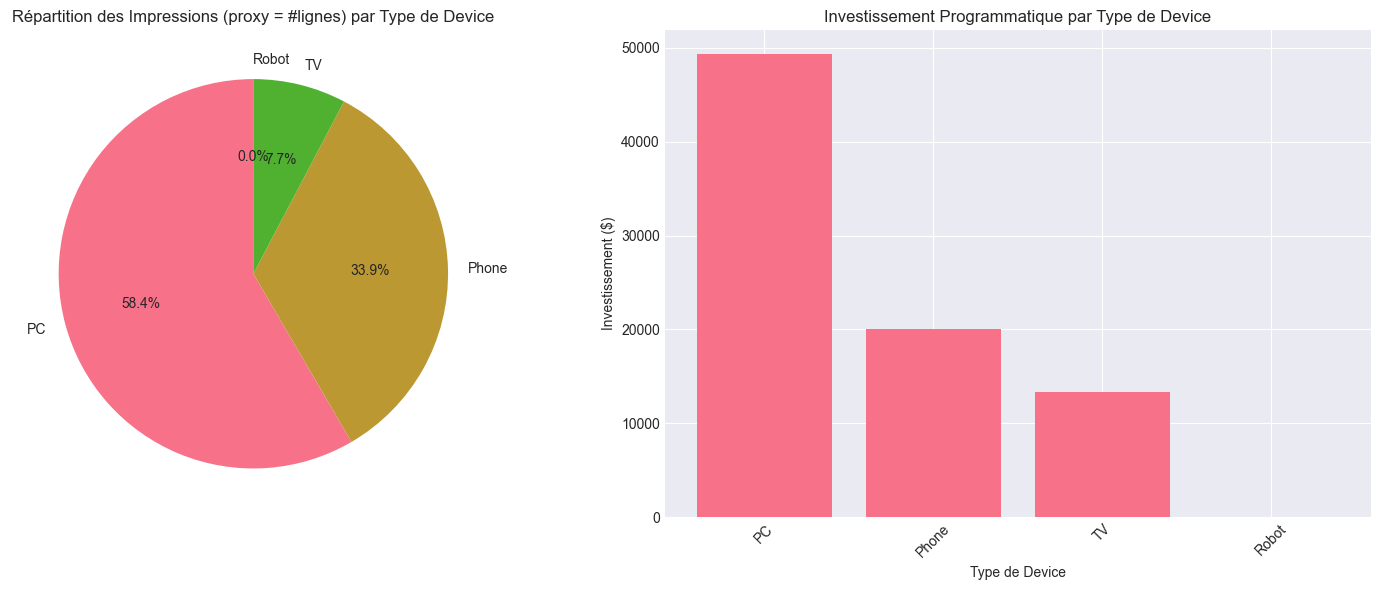

In [ ]:
print("PROGRAMMATIQUE — DISTRIBUTION PAR TYPE DE DEVICE (sans 'Unknown')")
print("=" * 80)

df_prog_clean = df_prog.copy()

# Nettoyage + suppression des catégories "Unknown"
df_prog_clean["device_type"] = df_prog_clean["device_type"].fillna("").astype(str).str.strip()

bad_device = {"", "unknown", "Unknown", "UNKNOWN", "nan", "NaN", "None"}
df_prog_clean = df_prog_clean[~df_prog_clean["device_type"].isin(bad_device)].copy()

# (Optionnel) filtrer aussi les dsp_id placeholders si tu veux cohérence globale
if "dsp_id" in df_prog_clean.columns:
    df_prog_clean = df_prog_clean[~df_prog_clean["dsp_id"].isin(BAD_IDS)].copy()

# Impressions: si colonne impressions existe, sinon proxy = nombre de lignes
if "impressions" in df_prog_clean.columns:
    device_impressions = (df_prog_clean.groupby("device_type")["impressions"]
                          .sum()
                          .sort_values(ascending=False))
    impressions_label = "Impressions"
else:
    device_impressions = df_prog_clean["device_type"].value_counts()
    impressions_label = "Impressions (proxy = #lignes)"

print(impressions_label + " par device:")
print(device_impressions)

device_cost = (df_prog_clean.groupby("device_type")["cost_dollar"]
               .sum()
               .sort_values(ascending=False))
print("\nInvestissement ($) par device:")
print(device_cost)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].pie(device_impressions.values, labels=device_impressions.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title(f"Répartition des {impressions_label} par Type de Device")

axes[1].bar(device_cost.index, device_cost.values)
axes[1].set_xlabel("Type de Device")
axes[1].set_ylabel("Investissement ($)")
axes[1].set_title("Investissement Programmatique par Type de Device")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 4.8 Analyse Multicanal Avancée

In [ ]:
# 1) TV exposures -> customer_id via mapping (en excluant unknown)
map_tv = (df_mapping[["customer_id","device_id"]]
          .dropna(subset=["device_id"])
          .loc[~df_mapping["device_id"].isin(BAD_IDS)]
          .drop_duplicates("customer_id"))

tv_events = (map_tv.merge(
                df_tv.loc[~df_tv["device_id"].isin(BAD_IDS), ["device_id","timestamp_utc","cost_dollar"]],
                on="device_id",
                how="inner"
            )
            .rename(columns={"timestamp_utc":"ts_ad", "cost_dollar":"cost"})
           )
tv_events["lever"] = "TV"
tv_events = tv_events[["customer_id","lever","ts_ad","cost"]]

# 2) Programmatic exposures -> customer_id via mapping (en excluant unknown)
map_prog = (df_mapping[["customer_id","dsp_id"]]
            .dropna(subset=["dsp_id"])
            .loc[~df_mapping["dsp_id"].isin(BAD_IDS)]
            .drop_duplicates("customer_id"))

prog_cols = ["dsp_id","timestamp_utc","cost_dollar"]
if "campaign_name" in df_prog.columns:
    prog_cols.append("campaign_name")
if "device_type" in df_prog.columns:
    prog_cols.append("device_type")

prog_events = (map_prog.merge(
                  df_prog.loc[~df_prog["dsp_id"].isin(BAD_IDS), prog_cols],
                  on="dsp_id",
                  how="inner"
              )
              .rename(columns={"timestamp_utc":"ts_ad", "cost_dollar":"cost"})
             )
prog_events["lever"] = "Programmatic"
keep_cols = ["customer_id","lever","ts_ad","cost"] + [c for c in ["campaign_name","device_type"] if c in prog_events.columns]
prog_events = prog_events[keep_cols]

# 3) Union
events = pd.concat([tv_events, prog_events], ignore_index=True)
events["ts_ad"] = pd.to_datetime(events["ts_ad"], errors="coerce")
events = events.dropna(subset=["ts_ad"])

print("events shape:", events.shape)
events.head()


events shape: (20816342, 6)


,customer_id,lever,ts_ad,cost,campaign_name,device_type
0,reFs5GI87lXJkJSi9r,TV,2024-04-23 21:09:46,0.023255,NaN,NaN
1,reWpqrLKjcWSuRWuaA,TV,2024-04-19 18:31:30,0.023255,NaN,NaN
2,rePoQMCHjXWhVRzxUJ,TV,2024-05-07 23:32:37,0.023255,NaN,NaN
3,rexfE5nZsqCSuheZfX,TV,2024-06-28 00:10:10,0.023255,NaN,NaN
4,regGxzWr07W4AQfWUI,TV,2024-05-24 03:45:45,0.023255,NaN,NaN


In [ ]:
lever_kpis = (events.groupby("lever")
              .agg(
                  reach=("customer_id","nunique"),
                  impressions=("customer_id","size"),   # proxy = nb lignes d'expo
                  spend=("cost","sum")
              )
              .assign(freq=lambda d: d["impressions"]/d["reach"])
              .sort_values("reach", ascending=False)
             )

display(lever_kpis)


,reach,impressions,spend,freq
lever,,,,
Programmatic,4999660,15275432,81176.087668,3.055294
TV,2024362,5540910,128854.461081,2.737114


In [ ]:
conv_tv = 0 if ("m_tv" not in globals() or len(m_tv)==0) else len(m_tv)
conv_prog = 0 if ("m_prog" not in globals() or len(m_prog)==0) else len(m_prog)

buyers_tv = 0 if ("m_tv" not in globals() or len(m_tv)==0) else m_tv["customer_id"].nunique()
buyers_prog = 0 if ("m_prog" not in globals() or len(m_prog)==0) else m_prog["customer_id"].nunique()

sales_tv = 0.0 if ("m_tv" not in globals() or len(m_tv)==0) else float(m_tv["sales"].sum())
sales_prog = 0.0 if ("m_prog" not in globals() or len(m_prog)==0) else float(m_prog["sales"].sum())

conv_kpis = pd.DataFrame({
    "lever": ["TV", "Programmatic"],
    "attributed_purchases": [conv_tv, conv_prog],
    "attributed_buyers": [buyers_tv, buyers_prog],
    "attributed_sales": [sales_tv, sales_prog],
})

# Ajout reach/impressions/spend pour calculer rates
conv_kpis = conv_kpis.merge(lever_kpis.reset_index(), on="lever", how="left")
conv_kpis["conversion_rate_per_reached"] = conv_kpis["attributed_buyers"] / conv_kpis["reach"]
conv_kpis["CPA_per_purchase"] = conv_kpis["spend"] / conv_kpis["attributed_purchases"]
conv_kpis["ROI_pct_attributed"] = (conv_kpis["attributed_sales"] - conv_kpis["spend"]) / conv_kpis["spend"] * 100

display(conv_kpis)


,lever,attributed_purchases,attributed_buyers,attributed_sales,reach,impressions,spend,freq,conversion_rate_per_reached,CPA_per_purchase,ROI_pct_attributed
0,TV,8108,6816,352100.96,2024362,5540910,128854.461081,2.737114,0.003367,15.892262,173.254769
1,Programmatic,109859,83014,4743423.19,4999660,15275432,81176.087668,3.055294,0.016604,0.738912,5743.374972


In [ ]:
p = df_purchases.copy()
p["ts_purchase"] = pd.to_datetime(p["timestamp_utc"], errors="coerce")
p = p.dropna(subset=["ts_purchase"])
p = p[["customer_id","ts_purchase","sales"]]

In [ ]:
WINDOW_H = 168

m_all = p.merge(events[["customer_id","lever","ts_ad"]], on="customer_id", how="left")
m_all["dt_h"] = (m_all["ts_purchase"] - m_all["ts_ad"]).dt.total_seconds()/3600
m_all = m_all[m_all["dt_h"].between(0, WINDOW_H, inclusive="both")].copy()

# first touch par levier (min ts_ad dans la fenêtre)
first_touch = (m_all.sort_values("ts_ad")
               .groupby(["customer_id","ts_purchase","lever"], as_index=False)
               .first()[["customer_id","ts_purchase","lever","ts_ad","sales"]])

pv = first_touch.pivot_table(index=["customer_id","ts_purchase","sales"], columns="lever", values="ts_ad", aggfunc="min").reset_index()

def order_row(r):
    tv = r.get("TV")
    pr = r.get("Programmatic")
    if pd.isna(tv) and pd.isna(pr): return "No exposure"
    if pd.isna(pr): return "TV only"
    if pd.isna(tv): return "Prog only"
    return "TV→Prog" if tv < pr else "Prog→TV"

pv["order"] = pv.apply(order_row, axis=1)

order_kpis = (pv.groupby("order")
              .agg(purchases=("sales","size"),
                   buyers=("customer_id","nunique"),
                   sales=("sales","sum"))
              .sort_values("purchases", ascending=False))

display(order_kpis)


,purchases,buyers,sales
order,,,
Prog only,109576,82822,4731009.35
TV only,7825,6612,339622.37
TV→Prog,189,162,7954.77
Prog→TV,94,86,4523.82


In [ ]:
if "m_prog" in globals() and len(m_prog) > 0 and "campaign_name" in m_prog.columns:
    camp = (m_prog.groupby("campaign_name")
            .agg(attributed_sales=("sales","sum"),
                 cost=("cost_dollar","sum"),
                 purchases=("sales","size"),
                 buyers=("customer_id","nunique"))
            .reset_index())
    camp["roi_pct"] = np.where(camp["cost"]>0, (camp["attributed_sales"]-camp["cost"])/camp["cost"]*100, np.nan)
    display(camp.sort_values("roi_pct", ascending=False).head(10))


,campaign_name,attributed_sales,cost,purchases,buyers,roi_pct
0,Contextual,479160.88,70.378920,11469,9118,680730.114520
1,Retargeting,4264262.31,1969.082678,98390,74806,216460.856396


In [ ]:
if "device_type" in events.columns:
    dev = (events[events["lever"]=="Programmatic"]
           .groupby("device_type")
           .agg(reach=("customer_id","nunique"),
                impressions=("customer_id","size"),
                spend=("cost","sum"))
           .sort_values("reach", ascending=False))
    display(dev)


,reach,impressions,spend
device_type,,,
PC,3326029,8920971,48407.425596
Phone,2004287,5176091,19657.851889
TV,675675,1177745,13107.115312
Unknown,455,614,3.661221
Robot,8,11,0.033650


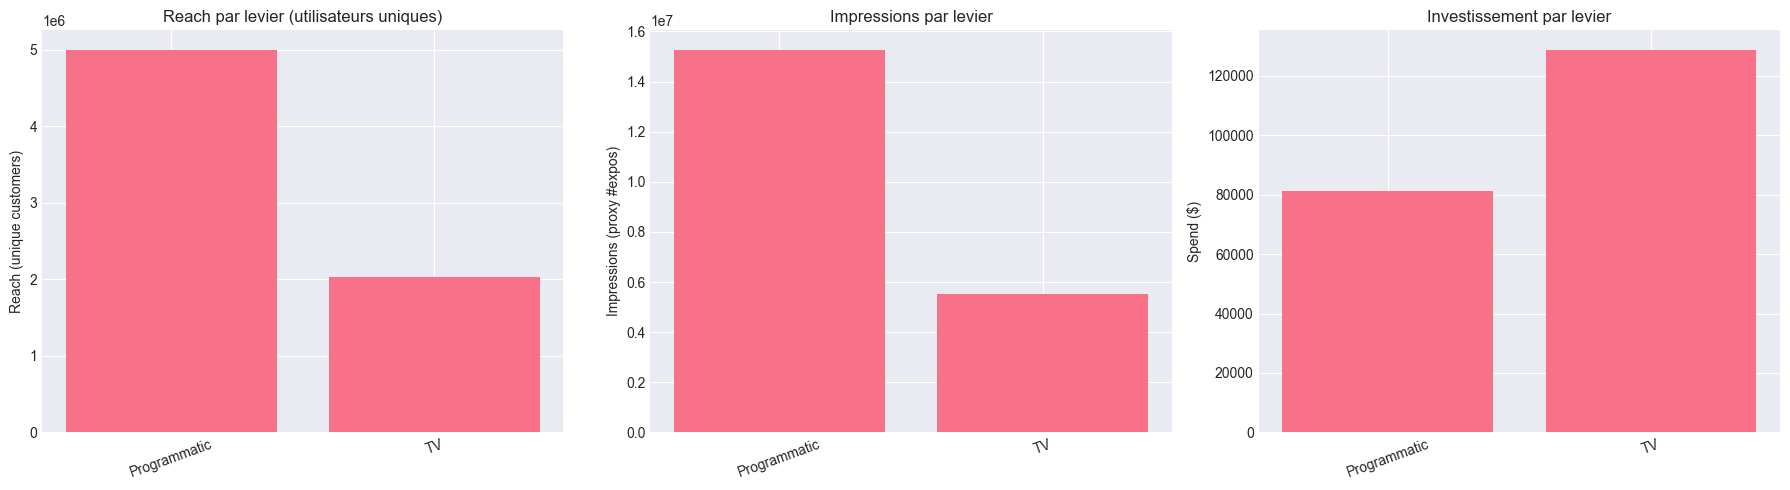

In [ ]:
# lever_kpis attendu: index=lever, colonnes reach, impressions, spend
df = lever_kpis.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(df.index, df["reach"])
axes[0].set_title("Reach par levier (utilisateurs uniques)")
axes[0].set_ylabel("Reach (unique customers)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(df.index, df["impressions"])
axes[1].set_title("Impressions par levier")
axes[1].set_ylabel("Impressions (proxy #expos)")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(df.index, df["spend"])
axes[2].set_title("Investissement par levier")
axes[2].set_ylabel("Spend ($)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


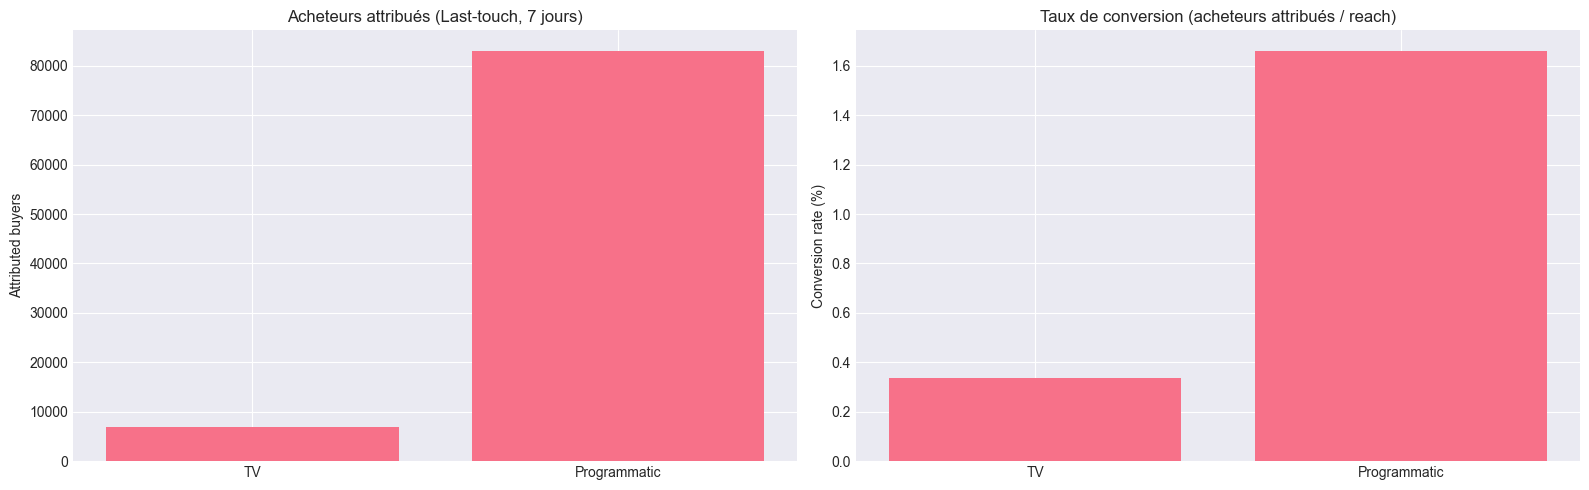

In [ ]:
# conv_kpis attendu: colonnes lever, attributed_buyers, attributed_purchases, attributed_sales, reach
df = conv_kpis.copy()

df["conv_rate_reach"] = np.where(df["reach"] > 0, df["attributed_buyers"] / df["reach"], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(df["lever"], df["attributed_buyers"])
axes[0].set_title("Acheteurs attribués (Last-touch, 7 jours)")
axes[0].set_ylabel("Attributed buyers")

axes[1].bar(df["lever"], df["conv_rate_reach"] * 100)
axes[1].set_title("Taux de conversion (acheteurs attribués / reach)")
axes[1].set_ylabel("Conversion rate (%)")

plt.tight_layout()
plt.show()


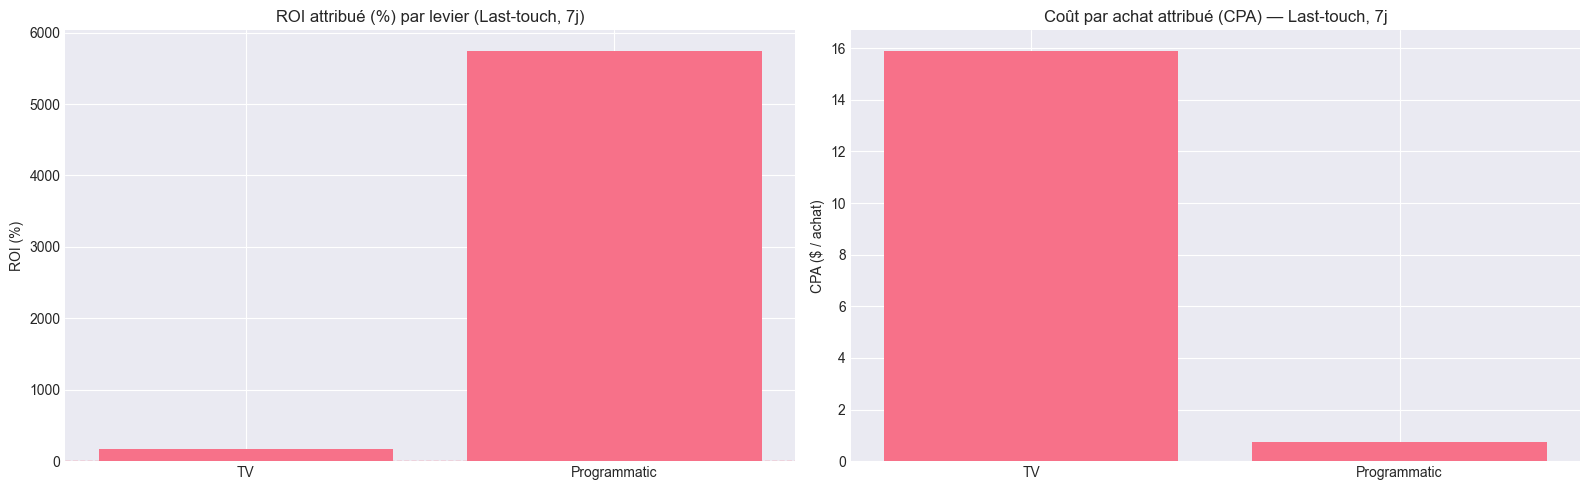

In [ ]:
df = conv_kpis.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(df["lever"], df["ROI_pct_attributed"])
axes[0].set_title("ROI attribué (%) par levier (Last-touch, 7j)")
axes[0].set_ylabel("ROI (%)")
axes[0].axhline(0, linestyle="--", linewidth=1)

axes[1].bar(df["lever"], df["CPA_per_purchase"])
axes[1].set_title("Coût par achat attribué (CPA) — Last-touch, 7j")
axes[1].set_ylabel("CPA ($ / achat)")

plt.tight_layout()
plt.show()


,purchases,buyers,sales,avg_basket
order,,,,
Prog only,109576,82822,4731009.35,43.175598
TV only,7825,6612,339622.37,43.402220
TV→Prog,189,162,7954.77,42.088730
Prog→TV,94,86,4523.82,48.125745


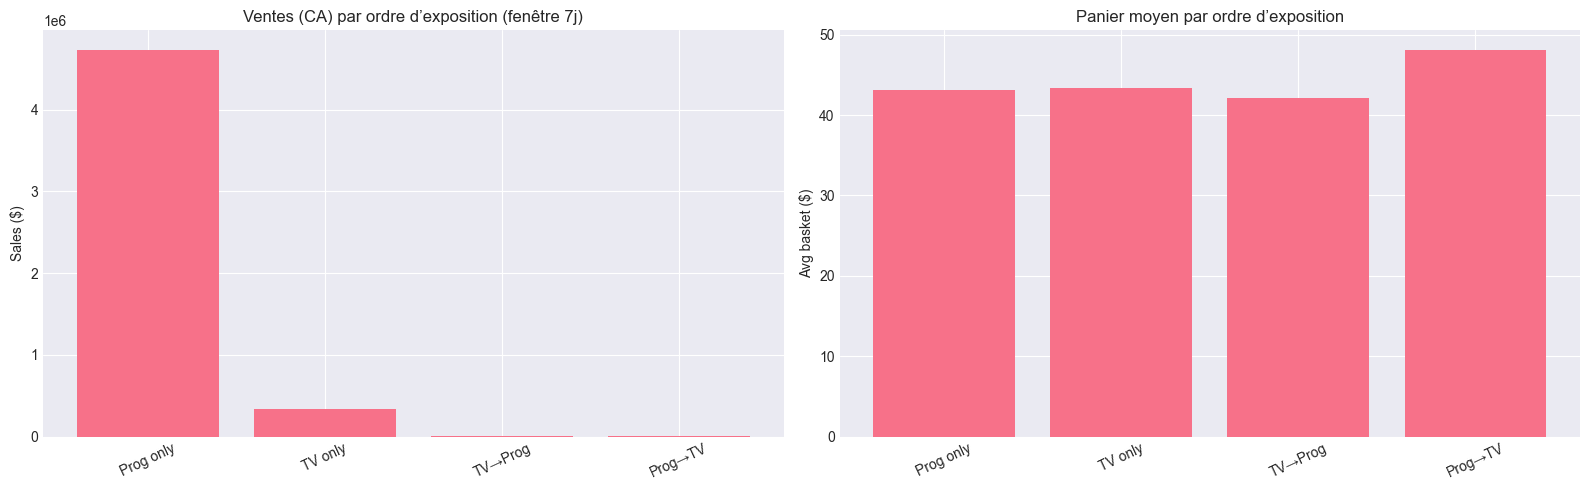

In [ ]:
# pv attendu: colonnes ["customer_id","ts_purchase","sales","order"]
df = pv.copy()

order_stats = (df.groupby("order")
               .agg(purchases=("sales","size"),
                    buyers=("customer_id","nunique"),
                    sales=("sales","sum"),
                    avg_basket=("sales","mean"))
               .sort_values("purchases", ascending=False))

display(order_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(order_stats.index, order_stats["sales"])
axes[0].set_title("Ventes (CA) par ordre d’exposition (fenêtre 7j)")
axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(order_stats.index, order_stats["avg_basket"])
axes[1].set_title("Panier moyen par ordre d’exposition")
axes[1].set_ylabel("Avg basket ($)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


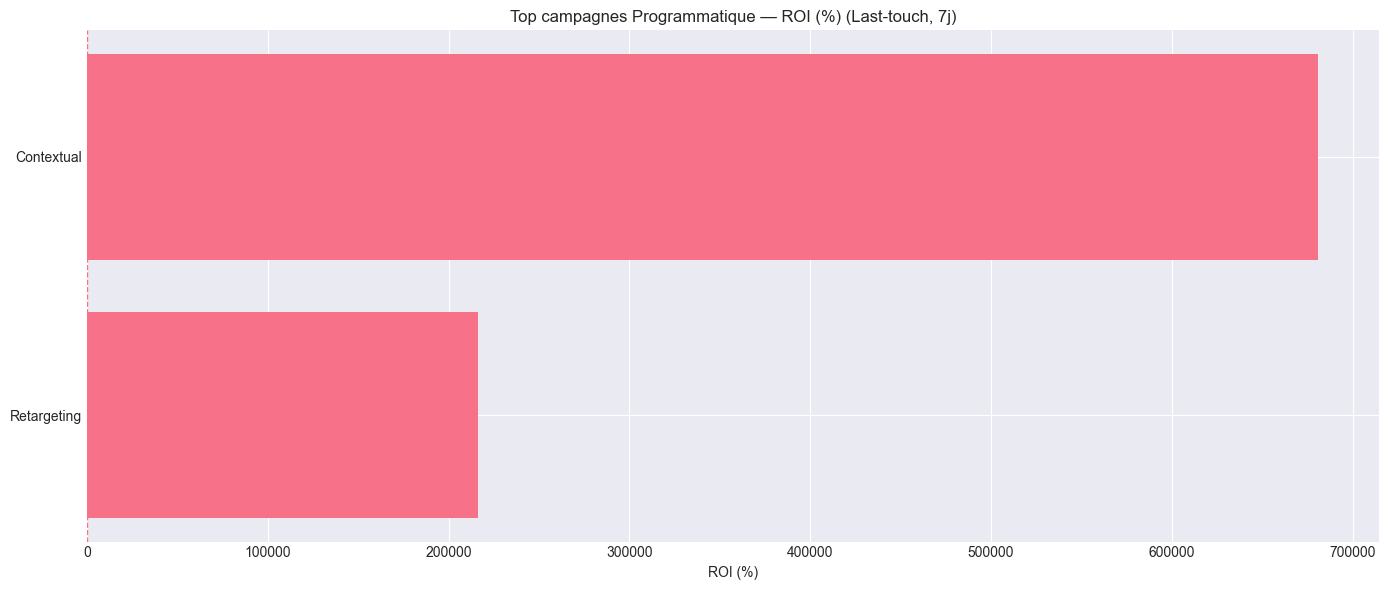

In [ ]:
# campaign_perf attendu: colonnes ["campaign","roi_pct","attributed_sales","cost",...]
top = campaign_perf.dropna(subset=["roi_pct"]).sort_values("roi_pct", ascending=False).head(12).copy()

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.barh(top["campaign"], top["roi_pct"])
ax.set_title("Top campagnes Programmatique — ROI (%) (Last-touch, 7j)")
ax.set_xlabel("ROI (%)")
ax.axvline(0, linestyle="--", linewidth=1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


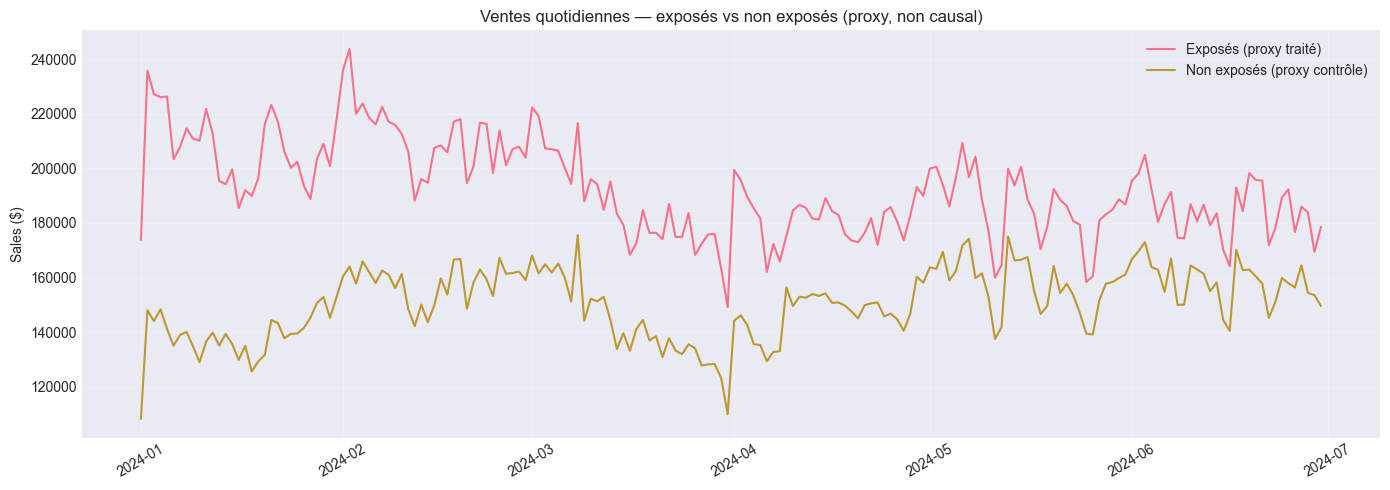

In [ ]:
# Exemple: comparer ventes quotidiennes des exposés vs non exposés (proxy, pas causal)
df = df_purchases.copy()
df["day"] = pd.to_datetime(df["timestamp_utc"]).dt.date

# exposed_any: clients qui apparaissent dans events
exposed_any = set(events["customer_id"].unique())
df["is_exposed"] = df["customer_id"].isin(exposed_any)

daily = (df.groupby(["day","is_exposed"])
         .agg(sales=("sales","sum"))
         .reset_index())

pivot = daily.pivot(index="day", columns="is_exposed", values="sales").fillna(0)
pivot.columns = ["control_not_exposed", "treated_exposed"]  # False, True

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(pivot.index, pivot["treated_exposed"], label="Exposés (proxy traité)")
ax.plot(pivot.index, pivot["control_not_exposed"], label="Non exposés (proxy contrôle)")
ax.set_title("Ventes quotidiennes — exposés vs non exposés (proxy, non causal)")
ax.set_ylabel("Sales ($)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:

df = conv_kpis.copy()

# Ratios utiles
df["conv_rate_reach_%"] = np.where(df["reach"] > 0, df["attributed_buyers"] / df["reach"] * 100, np.nan)
df["sales_per_buyer"] = np.where(df["attributed_buyers"] > 0, df["attributed_sales"] / df["attributed_buyers"], np.nan)
df["CPA_per_purchase"] = np.where(df["attributed_purchases"] > 0, df["spend"] / df["attributed_purchases"], np.nan)

# Table brute (numérique)
cols_num = ["reach","attributed_buyers","attributed_purchases","attributed_sales","spend","conv_rate_reach_%","sales_per_buyer","CPA_per_purchase","ROI_pct_attributed"]
table_num = df[["lever"] + cols_num].set_index("lever")
display(table_num.round(2))

# Table formatée (lisible)
table_fmt = table_num.copy()
table_fmt["reach"] = table_fmt["reach"].map(lambda x: f"{x:,.0f}")
table_fmt["attributed_buyers"] = table_fmt["attributed_buyers"].map(lambda x: f"{x:,.0f}")
table_fmt["attributed_purchases"] = table_fmt["attributed_purchases"].map(lambda x: f"{x:,.0f}")
table_fmt["attributed_sales"] = table_fmt["attributed_sales"].map(lambda x: f"{x:,.2f}")
table_fmt["spend"] = table_fmt["spend"].map(lambda x: f"{x:,.2f}")
table_fmt["conv_rate_reach_%"] = table_num["conv_rate_reach_%"].map(lambda x: f"{x:,.2f}%")
table_fmt["sales_per_buyer"] = table_num["sales_per_buyer"].map(lambda x: f"{x:,.2f}")
table_fmt["CPA_per_purchase"] = table_num["CPA_per_purchase"].map(lambda x: f"{x:,.3f}" if pd.notna(x) else "N/A")
table_fmt["ROI_pct_attributed"] = table_num["ROI_pct_attributed"].map(lambda x: f"{x:,.2f}%" if pd.notna(x) else "N/A")

print("CONVERSIONS — TABLEAU KPI (Last-touch, 7 jours)")
display(table_fmt)


,reach,attributed_buyers,attributed_purchases,attributed_sales,spend,conv_rate_reach_%,sales_per_buyer,CPA_per_purchase,ROI_pct_attributed
lever,,,,,,,,,
TV,2024362,6816,8108,352100.96,128854.46,0.34,51.66,15.89,173.25
Programmatic,4999660,83014,109859,4743423.19,81176.09,1.66,57.14,0.74,5743.37


CONVERSIONS — TABLEAU KPI (Last-touch, 7 jours)


,reach,attributed_buyers,attributed_purchases,attributed_sales,spend,conv_rate_reach_%,sales_per_buyer,CPA_per_purchase,ROI_pct_attributed
lever,,,,,,,,,
TV,"2,024,362","6,816","8,108","352,100.96","128,854.46",0.34%,51.66,15.892,173.25%
Programmatic,"4,999,660","83,014","109,859","4,743,423.19","81,176.09",1.66%,57.14,0.739,"5,743.37%"


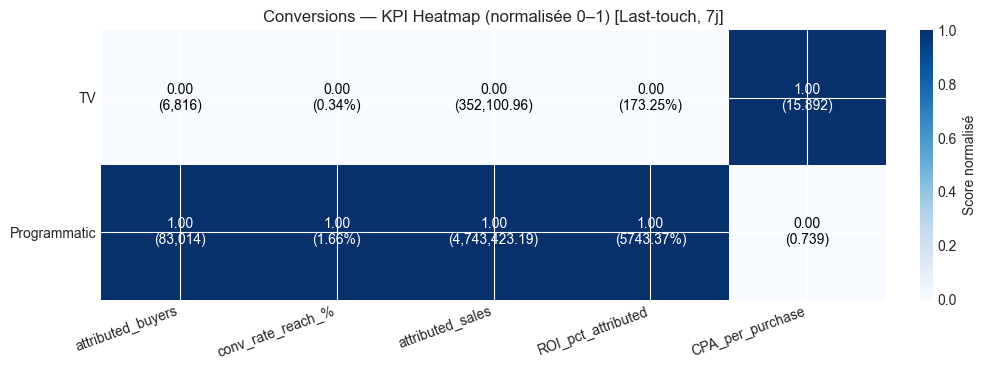

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# base numérique
df = conv_kpis.copy()
df["conv_rate_reach_%"] = np.where(df["reach"] > 0, df["attributed_buyers"] / df["reach"] * 100, np.nan)
df["sales_per_buyer"] = np.where(df["attributed_buyers"] > 0, df["attributed_sales"] / df["attributed_buyers"], np.nan)
df["CPA_per_purchase"] = np.where(df["attributed_purchases"] > 0, df["spend"] / df["attributed_purchases"], np.nan)

table_num = df.set_index("lever")[[
    "attributed_buyers", "conv_rate_reach_%", "attributed_sales",
    "ROI_pct_attributed", "CPA_per_purchase"
]].copy()

# normalisation 0-1 par colonne
X = table_num.copy()
Xn = (X - X.min()) / (X.max() - X.min()).replace(0, 1)

cols = list(Xn.columns)
rows = list(Xn.index)

fig, ax = plt.subplots(figsize=(10, 2.2 + 0.8*len(rows)))

# --- palette ---
cmap = plt.get_cmap("Blues")
im = ax.imshow(Xn.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_title("Conversions — KPI Heatmap (normalisée 0–1) [Last-touch, 7j]")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=20, ha="right")

# annotations: score + valeur brute
for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        val_norm = Xn.iloc[i, j]
        raw = X.loc[r, c]

        if c in ["conv_rate_reach_%", "ROI_pct_attributed"]:
            raw_s = f"{raw:.2f}%"
        elif c == "CPA_per_purchase":
            raw_s = f"{raw:.3f}" if pd.notna(raw) else "N/A"
        elif c == "attributed_buyers":
            raw_s = f"{raw:,.0f}"
        else:
            raw_s = f"{raw:,.2f}"

        # texte blanc sur cases foncées
        txt_color = "white" if val_norm > 0.55 else "black"
        ax.text(j, i, f"{val_norm:.2f}\n({raw_s})", ha="center", va="center", color=txt_color)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Score normalisé")
plt.tight_layout()
plt.show()


## 5. Insights et Recommandations

### 5.1 Synthèse des KPIs Clés


In [ ]:
# Création d'un tableau de bord récapitulatif
print("="*80)
print("TABLEAU DE BORD - SYNTHÈSE DES KPIs")
print("="*80)

print("\n📊 MARCHÉ ET VENTES")
print("-" * 80)
print(f"Chiffre d'affaires total: {df_purchases['sales'].sum():,.2f} $")
print(f"Nombre de transactions: {len(df_purchases):,}")
print(f"Nombre de clients uniques: {df_purchases['customer_id'].nunique():,}")
print(f"Panier moyen: {avg_basket:.2f} $")
print(f"Panier moyen par acheteur: {avg_basket_per_buyer:.2f} $")
print(f"Transactions moyennes par client: {avg_transactions:.2f}")

print("\n💰 INVESTISSEMENTS PUBLICITAIRES")
print("-" * 80)
print(f"Investissement TV: {tv_investment:,.2f} $")
print(f"Investissement Programmatique: {prog_investment:,.2f} $")
print(f"Investissement total: {tv_investment + prog_investment:,.2f} $")
print(f"Part du budget TV: {tv_investment/(tv_investment+prog_investment)*100:.1f}%")
print(f"Part du budget Programmatique: {prog_investment/(tv_investment+prog_investment)*100:.1f}%")

print("\n📈 PERFORMANCE PUBLICITAIRE")
print("-" * 80)
print(f"Ventes attribuées TV (7j): {tv_attributed_sales:,.2f} $")
print(f"Ventes attribuées Programmatique (7j): {prog_attributed_sales:,.2f} $")
print(f"ROI TV: {roi_tv:,.2f}%")
print(f"ROI Programmatique: {roi_prog:,.2f}%")
print(f"ROAS TV: {roas_tv:.2f}x")
print(f"ROAS Programmatique: {roas_prog:.2f}x")

print("\n👥 SEGMENTATION CLIENT")
print("-" * 80)
print(f"Acheteurs exposés TV: {len(buyers_with_tv):,} ({len(buyers_with_tv)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs exposés Programmatique: {len(buyers_with_prog):,} ({len(buyers_with_prog)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs exposés aux deux: {len(buyers_with_both):,} ({len(buyers_with_both)/len(all_buyers)*100:.1f}%)")
print(f"Acheteurs sans exposition pub: {len(buyers_no_ad):,} ({len(buyers_no_ad)/len(all_buyers)*100:.1f}%)")

print("\n" + "="*80)


### 5.2 Corrélation entre dépenses publicitaires et ventes


In [ ]:
# Calcul de la corrélation
from scipy import stats

# Corrélation entre dépenses pub totales et ventes (sur données quotidiennes)
ad_sales_clean = ad_sales_daily[ad_sales_daily['revenue'] > 0].copy()

corr_total, p_value_total = stats.pearsonr(ad_sales_clean['total_ad_cost'], ad_sales_clean['revenue'])
corr_tv, p_value_tv = stats.pearsonr(ad_sales_clean['tv_cost'], ad_sales_clean['revenue'])
corr_prog, p_value_prog = stats.pearsonr(ad_sales_clean['prog_cost'], ad_sales_clean['revenue'])

print("CORRÉLATION ENTRE DÉPENSES PUBLICITAIRES ET VENTES")
print("=" * 80)
print(f"Corrélation dépenses pub totales vs ventes: {corr_total:.3f} (p-value: {p_value_total:.4f})")
print(f"Corrélation dépenses TV vs ventes: {corr_tv:.3f} (p-value: {p_value_tv:.4f})")
print(f"Corrélation dépenses Programmatique vs ventes: {corr_prog:.3f} (p-value: {p_value_prog:.4f})")

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total ad cost vs revenue
axes[0].scatter(ad_sales_clean['total_ad_cost'], ad_sales_clean['revenue'], alpha=0.5)
axes[0].set_xlabel('Dépenses publicitaires totales ($)')
axes[0].set_ylabel('Chiffre d\'affaires ($)')
axes[0].set_title(f'Corrélation: {corr_total:.3f}')
z = np.polyfit(ad_sales_clean['total_ad_cost'], ad_sales_clean['revenue'], 1)
p = np.poly1d(z)
axes[0].plot(ad_sales_clean['total_ad_cost'], p(ad_sales_clean['total_ad_cost']), "r--", alpha=0.8)

# TV cost vs revenue
axes[1].scatter(ad_sales_clean['tv_cost'], ad_sales_clean['revenue'], alpha=0.5, color='orange')
axes[1].set_xlabel('Dépenses TV ($)')
axes[1].set_ylabel('Chiffre d\'affaires ($)')
axes[1].set_title(f'Corrélation TV: {corr_tv:.3f}')
if ad_sales_clean['tv_cost'].sum() > 0:
    z = np.polyfit(ad_sales_clean['tv_cost'], ad_sales_clean['revenue'], 1)
    p = np.poly1d(z)
    axes[1].plot(ad_sales_clean['tv_cost'], p(ad_sales_clean['tv_cost']), "r--", alpha=0.8)

# Prog cost vs revenue
axes[2].scatter(ad_sales_clean['prog_cost'], ad_sales_clean['revenue'], alpha=0.5, color='green')
axes[2].set_xlabel('Dépenses Programmatique ($)')
axes[2].set_ylabel('Chiffre d\'affaires ($)')
axes[2].set_title(f'Corrélation Prog: {corr_prog:.3f}')
if ad_sales_clean['prog_cost'].sum() > 0:
    z = np.polyfit(ad_sales_clean['prog_cost'], ad_sales_clean['revenue'], 1)
    p = np.poly1d(z)
    axes[2].plot(ad_sales_clean['prog_cost'], p(ad_sales_clean['prog_cost']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()
